# Time Series Forecasting of Illinois Suicide Mortality

**Authors:** Payton Stewart · Adaora Ezike · Eduardo Tovilla Rivera · Hoon Yum

---

In [1]:
# 00  LOAD PACKAGES

suppressPackageStartupMessages({
  library(dplyr)
  library(readr)
  library(lubridate)
  library(zoo)
  library(forecast)
  library(tseries)
  library(MASS)
  library(ggplot2)
  library(scales)
})

options(max.print = 99999, width = 200, dplyr.print_max = Inf)
options(repr.plot.width = 16, repr.plot.height = 6, repr.plot.res = 150)
theme_set(theme_minimal(base_size = 13))

---
# 01 Introduction & Data Pipeline

In [2]:
# LOAD & CLEAN & MERGE

raw_final <- suppressWarnings(read_csv("Multiple Cause of Death, 1999-2020.csv", show_col_types = FALSE))
raw_prov  <- suppressWarnings(read_csv("Provisional Mortality Statistics, 2018 through Last Week.csv", show_col_types = FALSE))

clean_cdc_data <- function(data) {
  data %>%
    filter(!is.na(`Month Code`)) %>%
    dplyr::select(date = `Month Code`, deaths = Deaths) %>%
    mutate(deaths = as.numeric(deaths)) %>%
    filter(!is.na(deaths))
}

df_final_clean <- clean_cdc_data(raw_final)
df_prov_clean  <- clean_cdc_data(raw_prov)

df_raw <- df_final_clean %>%
  bind_rows(df_prov_clean %>% filter(date >= "2021/01" & date <= "2024/12")) %>%
  arrange(date)

cat("Total observations:", nrow(df_raw), "(expected: 312)\n")
cat("Date range:", head(df_raw$date, 1), "to", tail(df_raw$date, 1), "\n")
cat("Total deaths:", format(sum(df_raw$deaths), big.mark = ","), "\n")

Total observations: 312 (expected: 312)
Date range: 1999/01 to 2024/12 
Total deaths: 33,227 


In [3]:
# CREATE TS OBJECT & TRAIN / TEST SPLIT
df <- df_raw %>%
  mutate(date       = as.Date(paste0(date, "/01"), format = "%Y/%m/%d"),
         year       = year(date),
         month_num  = month(date),
         month_name = month(date, label = TRUE))

full_ts    <- ts(df$deaths, start = c(year(min(df$date)), month(min(df$date))), frequency = 12)
train_ts   <- window(full_ts, end = c(2023, 12))
holdout_ts <- window(full_ts, start = c(2024, 1), end = c(2024, 12))

cat(sprintf("Train  : %d months\nHoldout: %d months\n", length(train_ts), length(holdout_ts)))

Train  : 300 months
Holdout: 12 months


---
# 02 Exploratory Data Analysis (EDA)

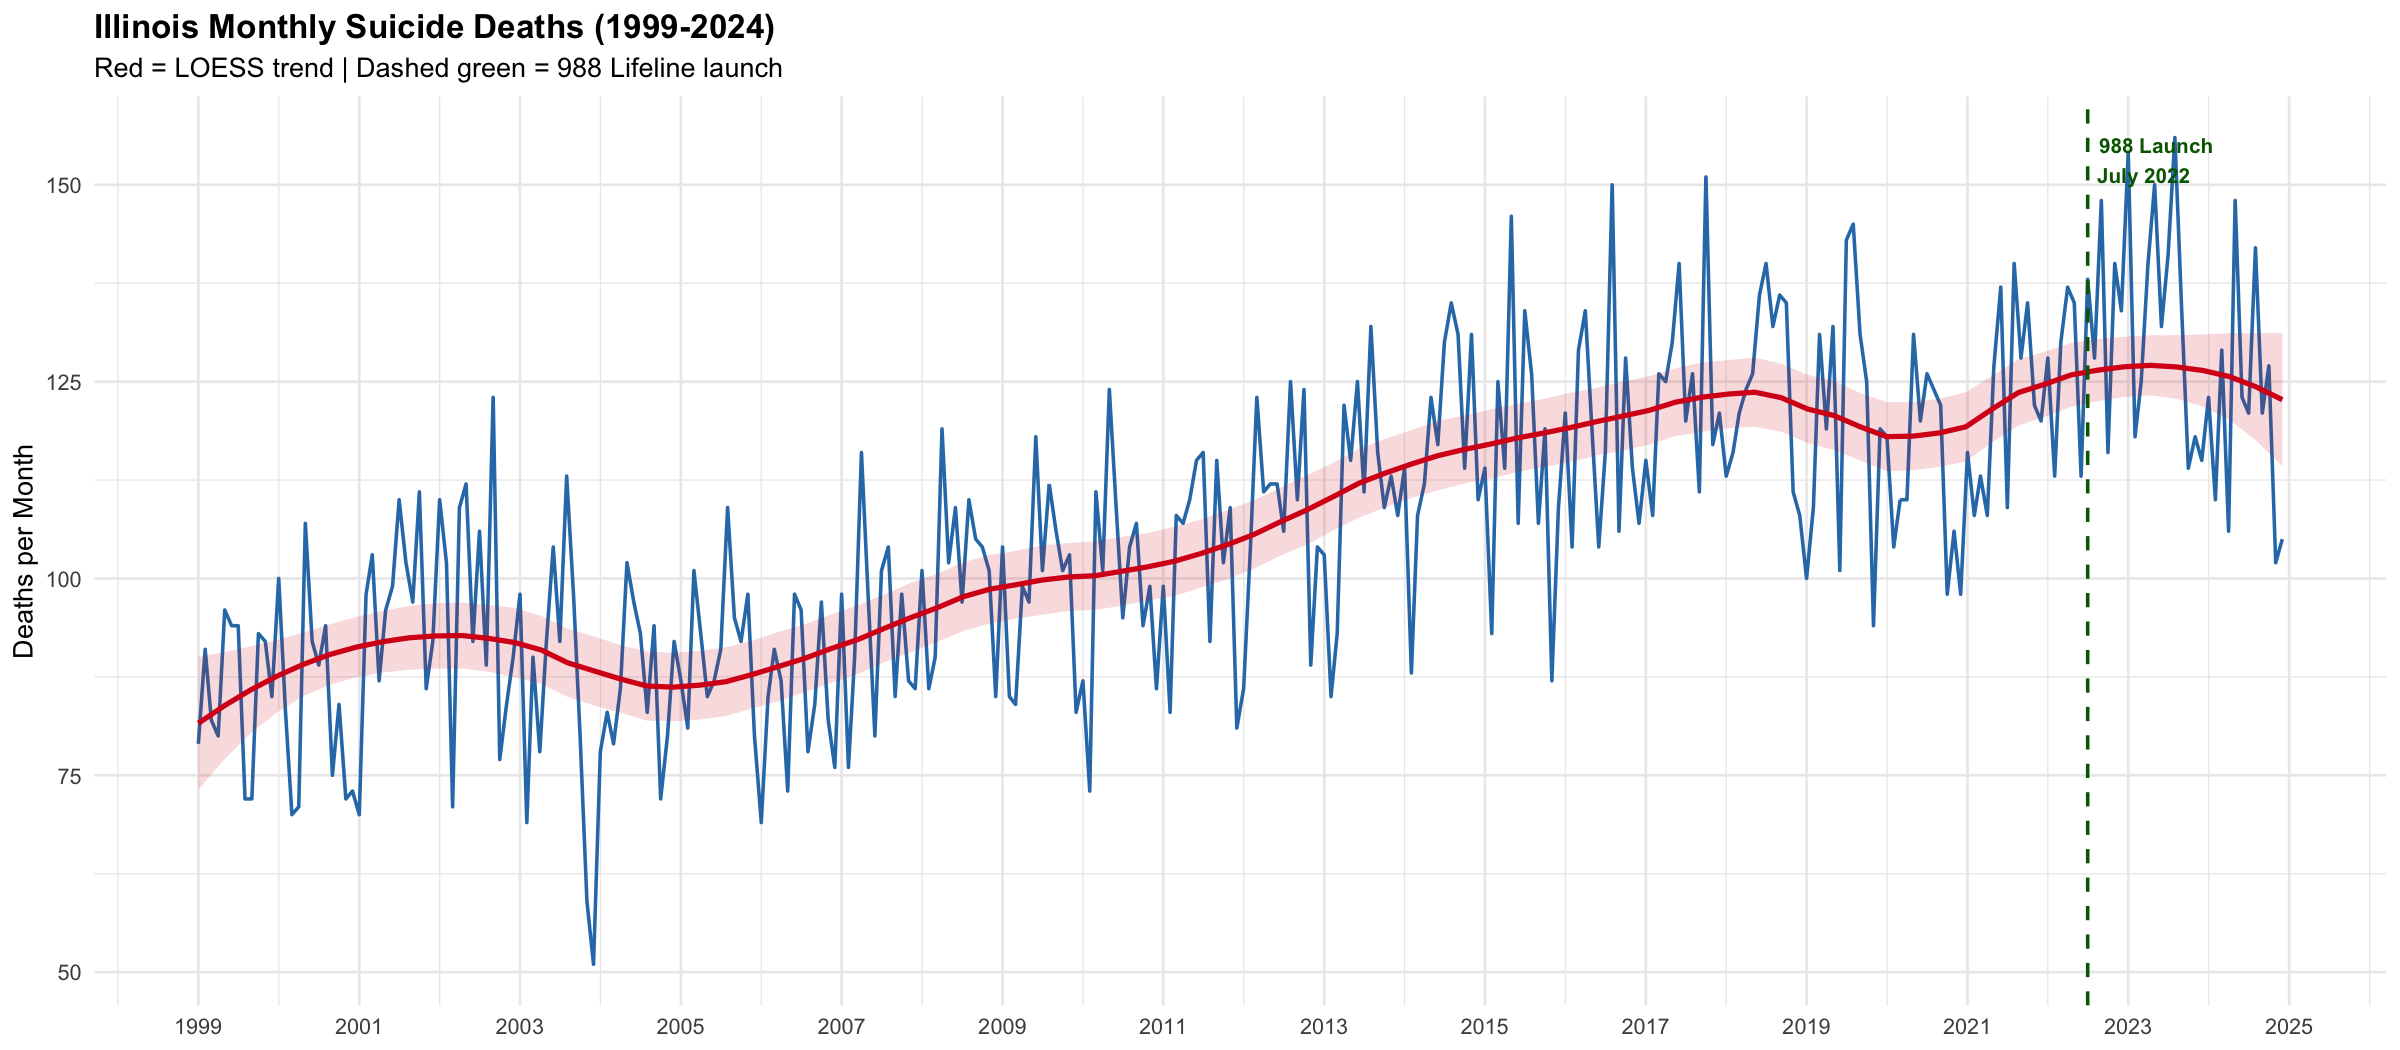

In [4]:
# Full Time Series + LOESS trend + 988 launch marker

options(repr.plot.width = 16, repr.plot.height = 7)

ggplot(df, aes(x = date, y = deaths)) +
  geom_line(color = "#2C7BB6", linewidth = 0.8) +
  geom_smooth(method = "loess", formula = y ~ x, span = 0.3, color = "#D7191C",
              se = TRUE, fill = "#D7191C", alpha = 0.15) +
  geom_vline(xintercept = as.Date("2022-07-01"),
             linetype = "dashed", color = "darkgreen", linewidth = 0.8) +
  annotate("text", x = as.Date("2022-07-01"), y = max(df$deaths, na.rm = TRUE),
           label = "988 Launch\nJuly 2022", hjust = -0.1, vjust = 1,
           color = "darkgreen", fontface = "bold", size = 3.5) +
  labs(title = "Illinois Monthly Suicide Deaths (1999-2024)",
       subtitle = "Red = LOESS trend | Dashed green = 988 Lifeline launch",
       x = NULL, y = "Deaths per Month") +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  theme(plot.title = element_text(face = "bold", size = 16))

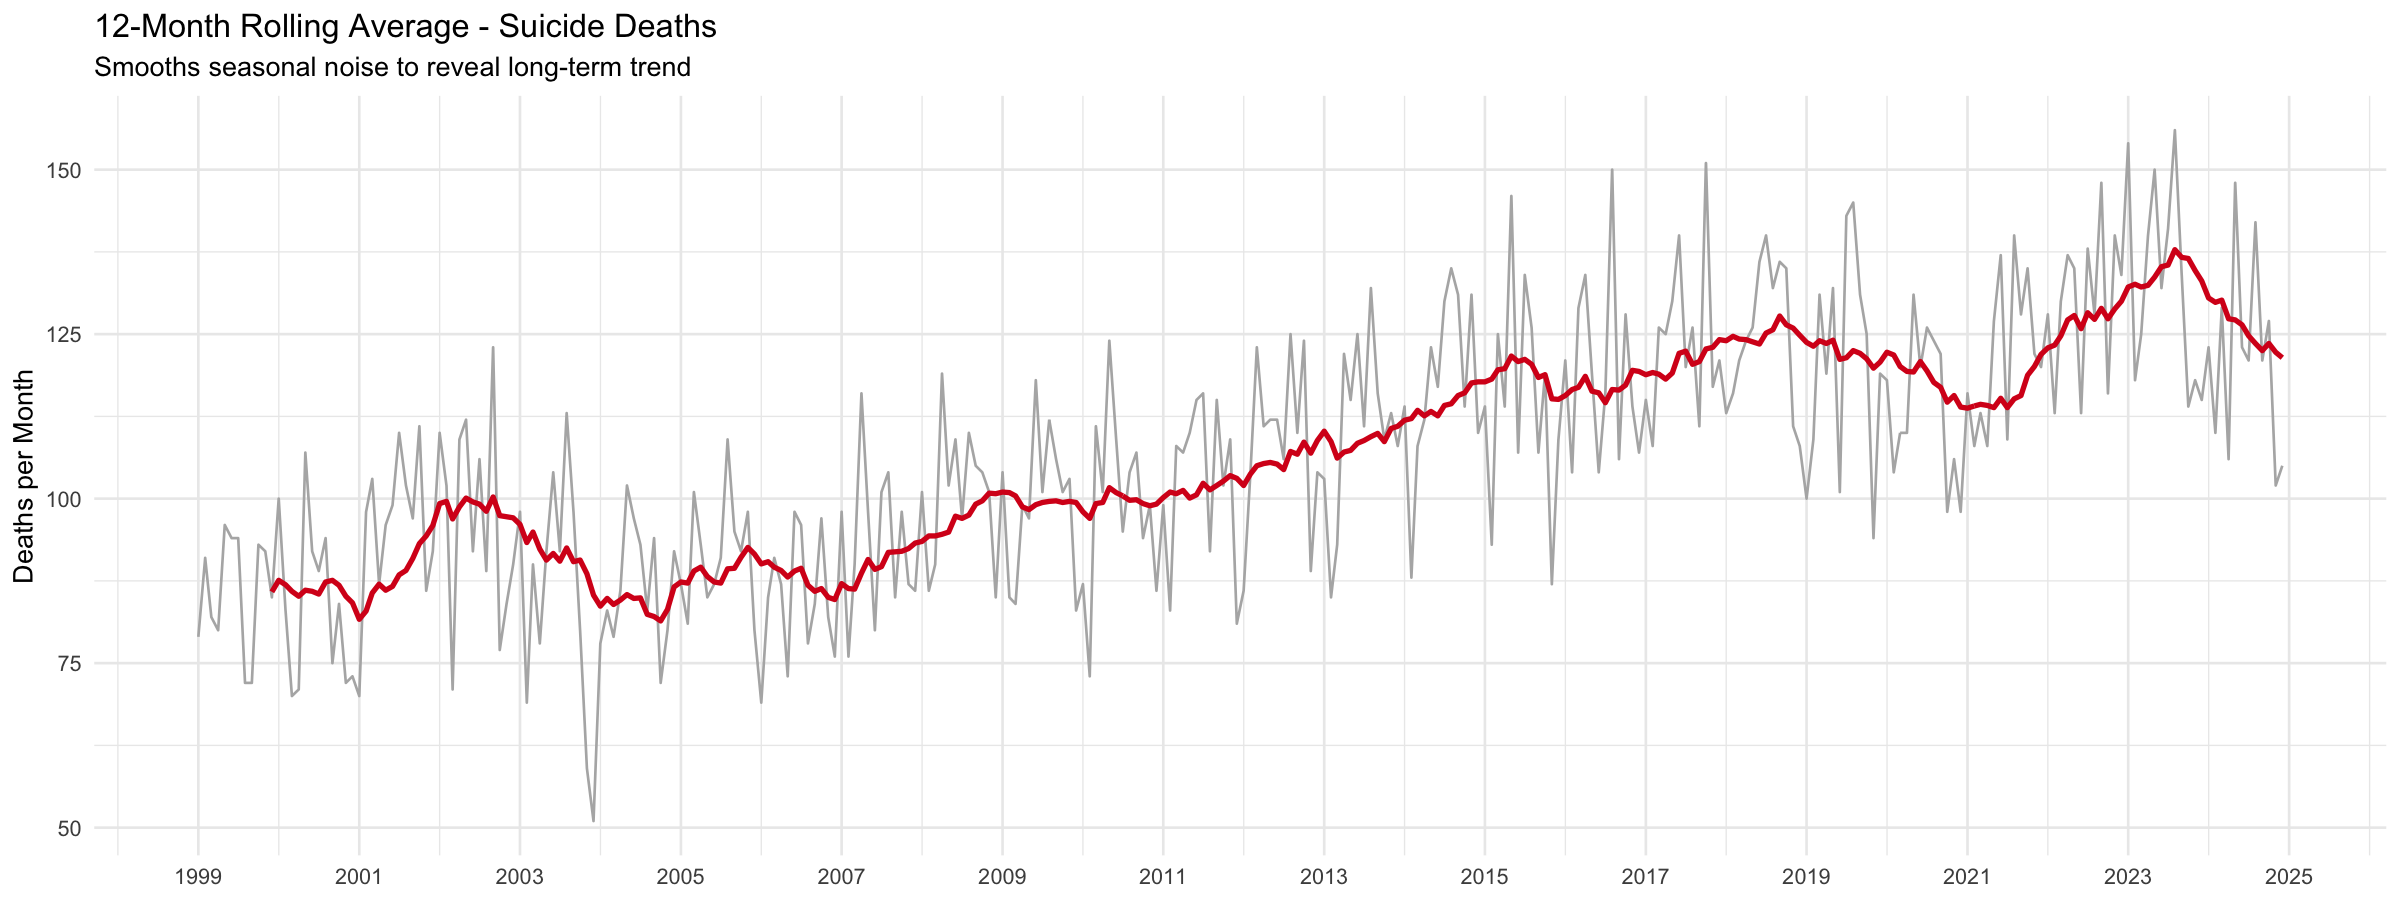

In [5]:
# 12-Month Rolling Average

options(repr.plot.width = 16, repr.plot.height = 6)
df <- df %>% mutate(rolling_12mo = rollmean(deaths, k = 12, fill = NA, align = "right"))

ggplot(df, aes(x = date)) +
  geom_line(aes(y = deaths), color = "gray70", linewidth = 0.6) +
  geom_line(aes(y = rolling_12mo), color = "#D7191C", linewidth = 1.2, na.rm = TRUE) +
  labs(title = "12-Month Rolling Average - Suicide Deaths",
       subtitle = "Smooths seasonal noise to reveal long-term trend",
       x = NULL, y = "Deaths per Month") +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y")

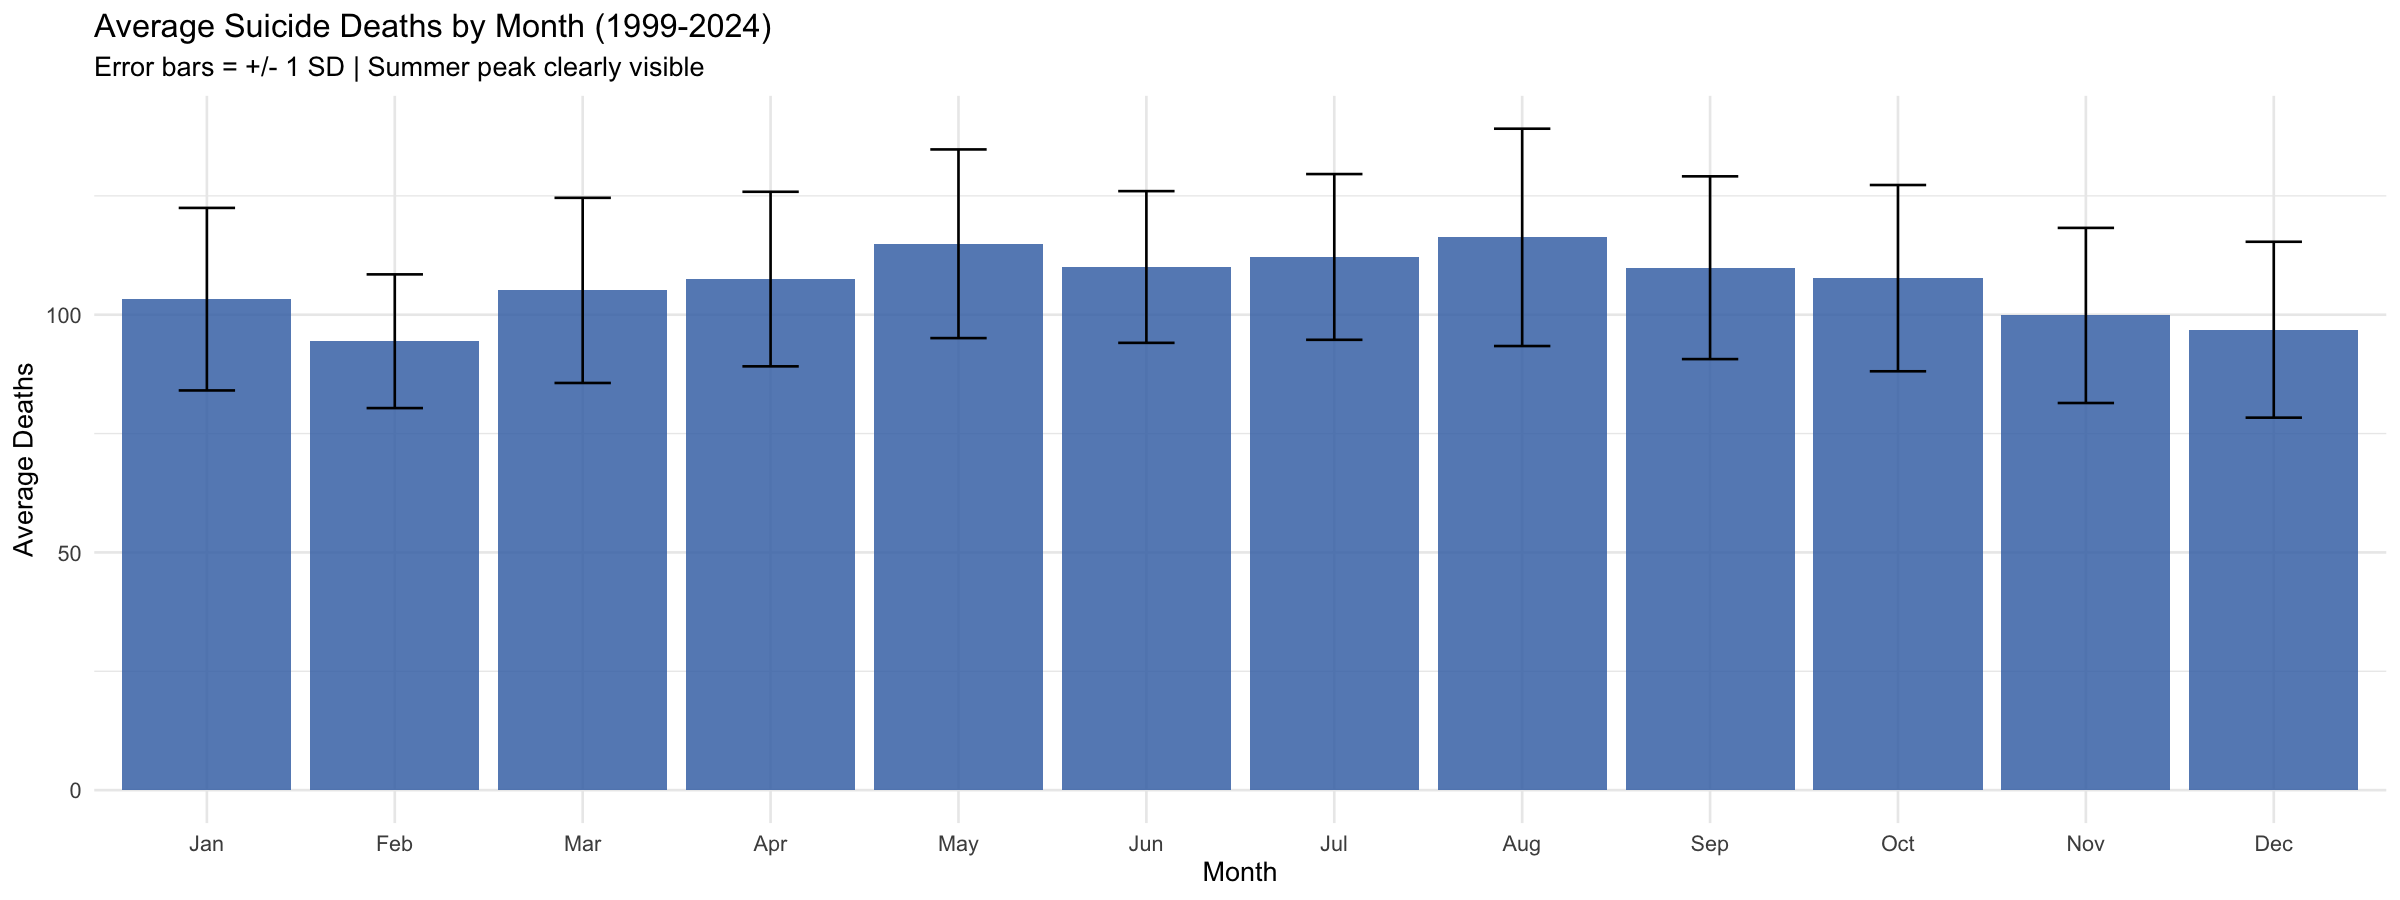

In [6]:
# Average Suicide Deaths by Month (Seasonality)

df %>%
  group_by(month_name) %>%
  summarise(mean_deaths = mean(deaths, na.rm = TRUE),
            sd_deaths   = sd(deaths, na.rm = TRUE), .groups = "drop") %>%
  ggplot(aes(x = month_name, y = mean_deaths)) +
  geom_col(fill = "#4575B4", alpha = 0.85) +
  geom_errorbar(aes(ymin = mean_deaths - sd_deaths,
                    ymax = mean_deaths + sd_deaths), width = 0.3) +
  labs(title = "Average Suicide Deaths by Month (1999-2024)",
       subtitle = "Error bars = +/- 1 SD | Summer peak clearly visible",
       x = "Month", y = "Average Deaths")

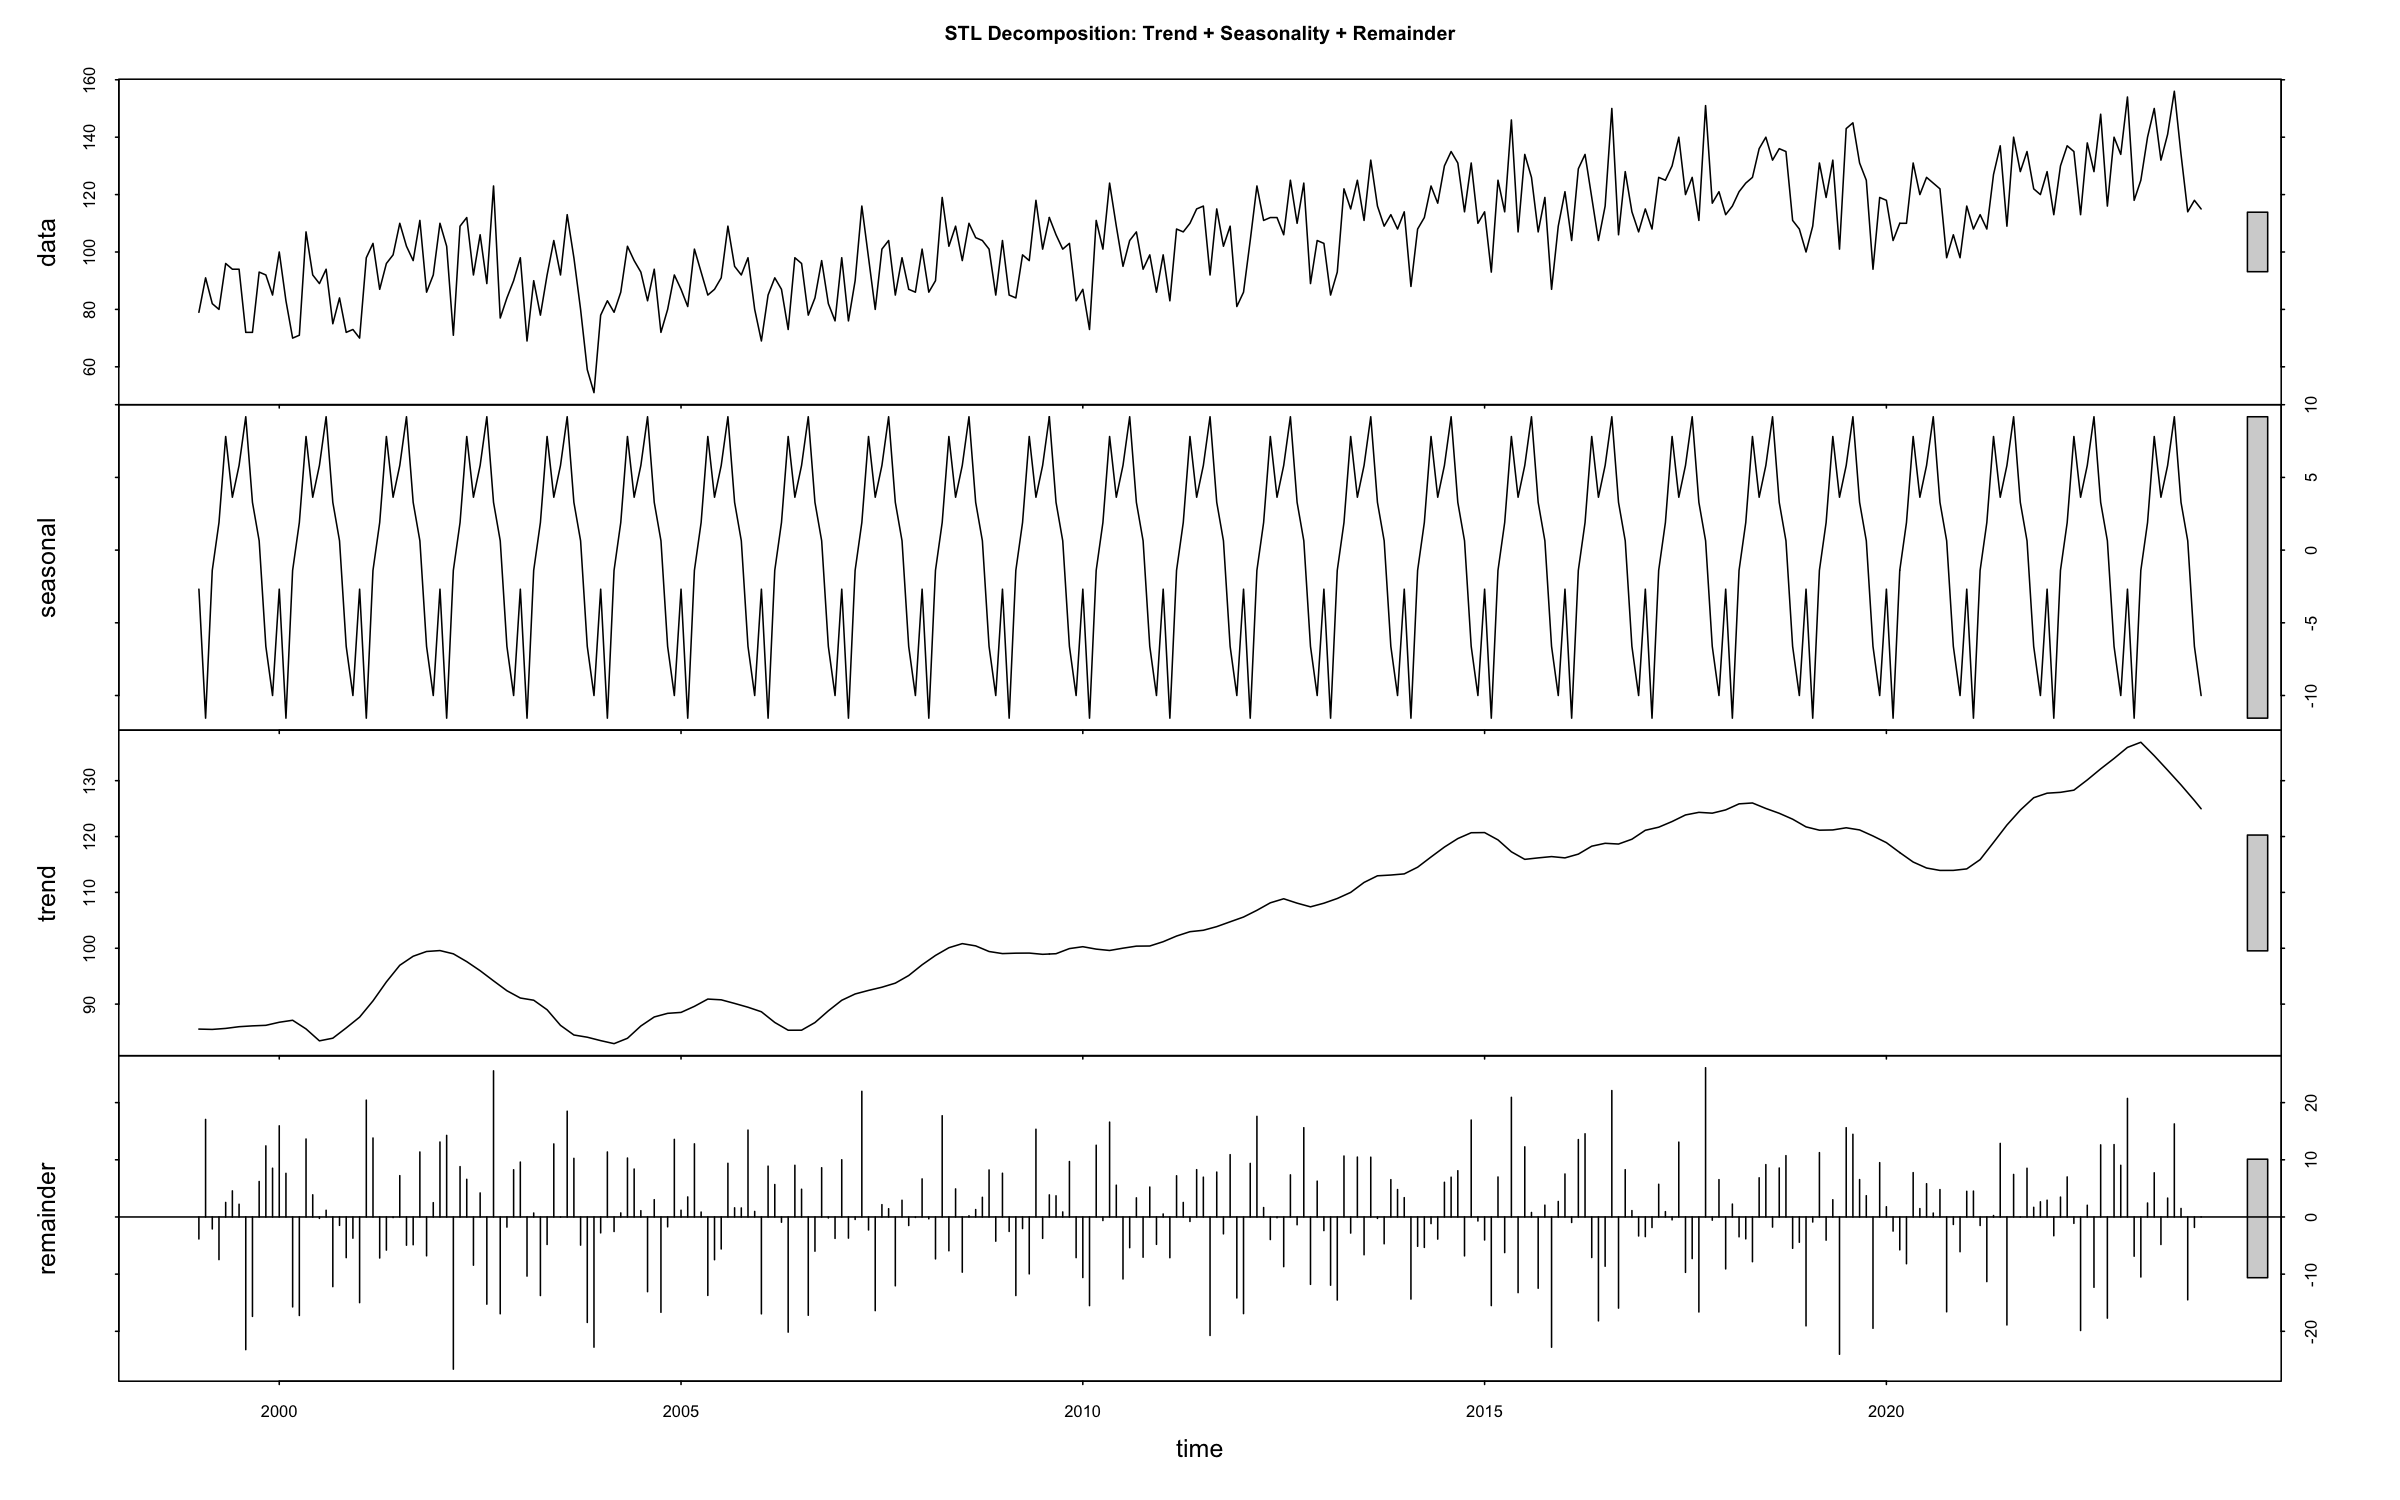

In [7]:
# STL Decomposition

options(repr.plot.width = 16, repr.plot.height = 10)
stl_result <- stl(train_ts, s.window = "periodic")
plot(stl_result, main = "STL Decomposition: Trend + Seasonality + Remainder")

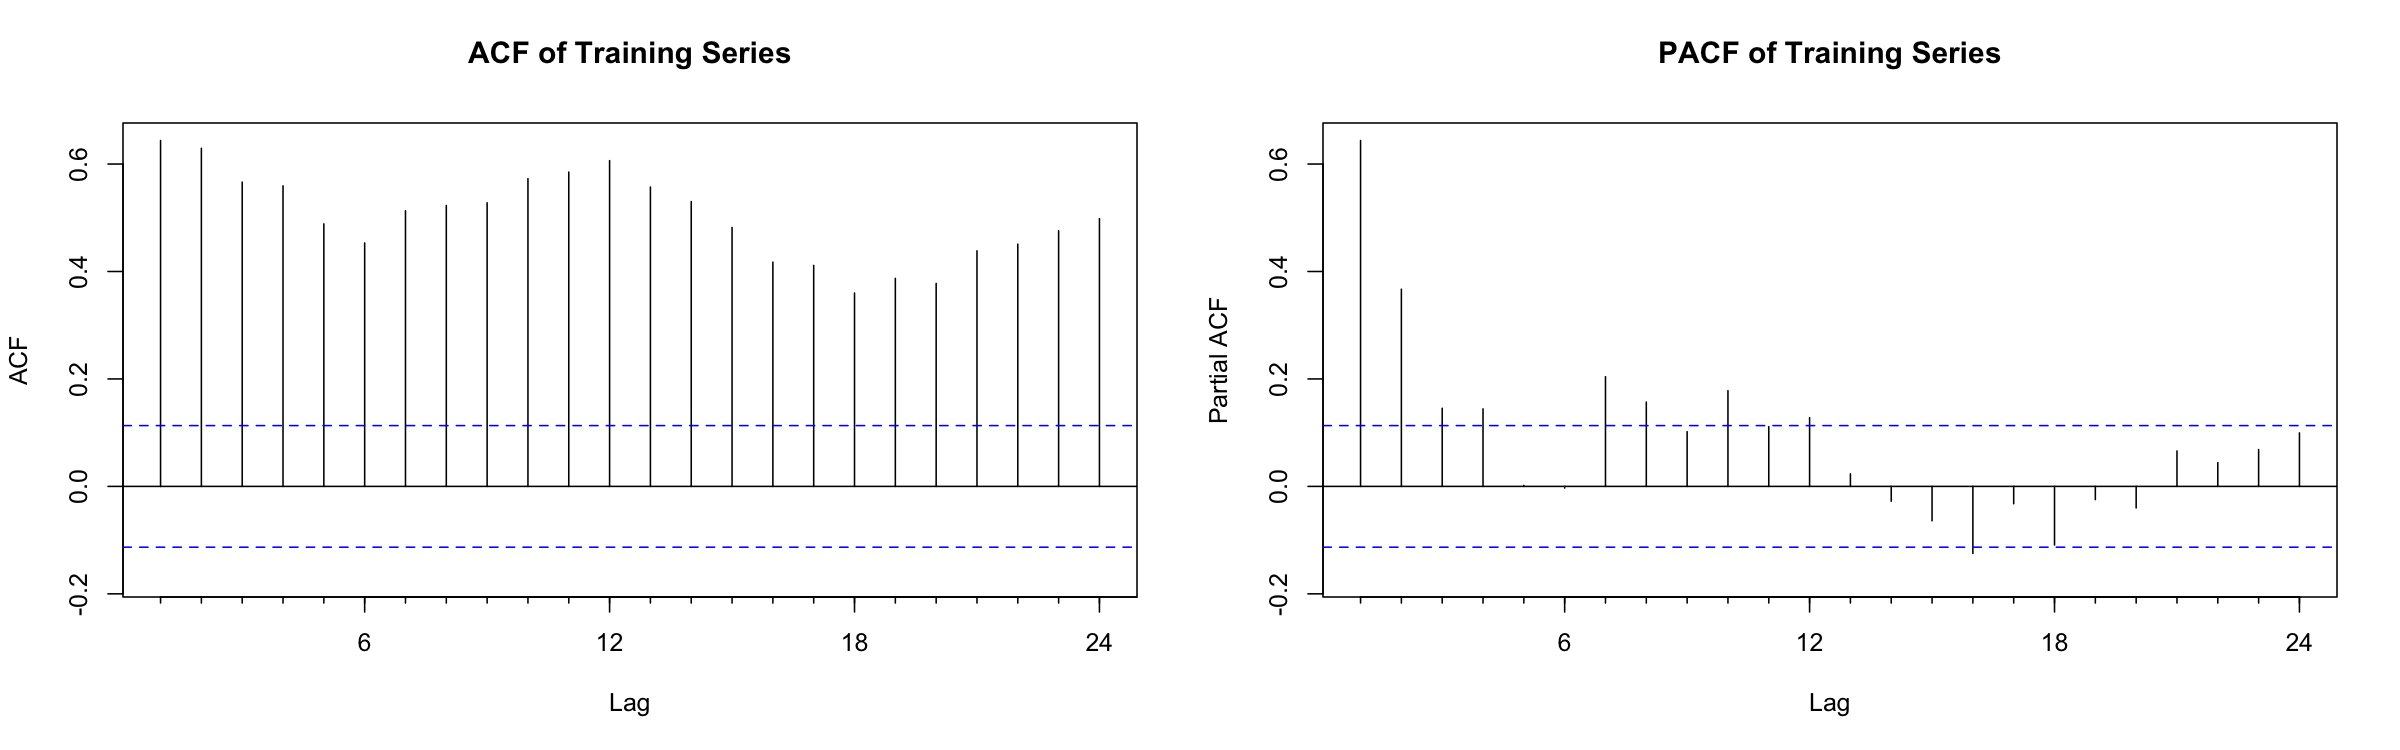

In [8]:
# ACF & PACF

options(repr.plot.width = 16, repr.plot.height = 5)
par(mfrow = c(1, 2))
Acf(train_ts,  main = "ACF of Training Series")
Pacf(train_ts, main = "PACF of Training Series")
par(mfrow = c(1, 1))

In [9]:
# Stationarity (ADF) & Box-Cox

adf_result <- adf.test(train_ts)
cat("=== Augmented Dickey-Fuller Test ===\n")
cat("Test statistic:", round(adf_result$statistic, 4), "\n")
cat("p-value:", adf_result$p.value, "\n")
cat("Conclusion:", ifelse(adf_result$p.value < 0.05,
    "Reject unit root", "Cannot reject unit root"), "\n\n")

lambda <- BoxCox.lambda(train_ts)
cat("Box-Cox Lambda:", round(lambda, 4), " -> near 1, no transform needed\n")

Warning message in adf.test(train_ts):
“p-value smaller than printed p-value”


=== Augmented Dickey-Fuller Test ===
Test statistic: -6.3453 
p-value: 0.01 
Conclusion: Reject unit root 

Box-Cox Lambda: 0.7512  -> near 1, no transform needed


---
# 03 Modeling: Poisson and Negative Binomial Regression

In [10]:
# PREPARE GLM DATA FRAMES

df_train <- data.frame(deaths = as.numeric(train_ts),
                       time   = seq_len(length(train_ts)),
                       month  = as.factor(cycle(train_ts)))

df_holdout <- data.frame(deaths = as.numeric(holdout_ts),
                         time   = (length(train_ts) + 1):(length(train_ts) + length(holdout_ts)),
                         month  = as.factor(cycle(holdout_ts)))

In [11]:
# POISSON REGRESSION

poisson_model    <- glm(deaths ~ time + month, data = df_train, family = poisson)
dispersion_ratio <- poisson_model$deviance / poisson_model$df.residual

k_po    <- length(coef(poisson_model))
n_po    <- nobs(poisson_model)
aic_po  <- AIC(poisson_model)
aicc_po <- aic_po + (2 * k_po * (k_po + 1)) / (n_po - k_po - 1)

po_pred  <- predict(poisson_model, newdata = df_holdout, type = "response")
po_error <- df_holdout$deaths - po_pred
po_rmse  <- sqrt(mean(po_error^2))
po_mape  <- mean(abs(po_error / df_holdout$deaths)) * 100

po_resid <- residuals(poisson_model, type = "deviance")
po_lb    <- Box.test(po_resid, lag = 12, type = "Ljung-Box")

cat("=== Poisson Regression ===\n")
cat("Dispersion Ratio:", round(dispersion_ratio, 2), "\n")
cat("AIC:", round(aic_po, 2), "| AICc:", round(aicc_po, 2), "\n")
cat("Holdout RMSE:", round(po_rmse, 2), "| MAPE:", round(po_mape, 2), "%\n")
cat("Ljung-Box p:", formatC(po_lb$p.value, format = "e", digits = 2), "\n")

=== Poisson Regression ===
Dispersion Ratio: 1.33 
AIC: 2353.04 | AICc: 2354.31 
Holdout RMSE: 15.71 | MAPE: 11.62 %
Ljung-Box p: 1.10e-08 


In [12]:
# NEGATIVE BINOMIAL REGRESSION

nb_model <- glm.nb(deaths ~ time + month, data = df_train)
summary(nb_model)

k_nb    <- length(coef(nb_model)) + 1
n_nb    <- nobs(nb_model)
aic_nb  <- AIC(nb_model)
aicc_nb <- aic_nb + (2 * k_nb * (k_nb + 1)) / (n_nb - k_nb - 1)

nb_pred  <- predict(nb_model, newdata = df_holdout, type = "response")
nb_error <- df_holdout$deaths - nb_pred
nb_rmse  <- sqrt(mean(nb_error^2))
nb_mape  <- mean(abs(nb_error / df_holdout$deaths)) * 100

nb_resid <- residuals(nb_model, type = "deviance")
nb_lb    <- Box.test(nb_resid, lag = 12, type = "Ljung-Box")

cat("\nAIC:", round(aic_nb, 2), "| AICc:", round(aicc_nb, 2), "\n")
cat("Holdout RMSE:", round(nb_rmse, 2), "| MAPE:", round(nb_mape, 2), "%\n")
cat("Ljung-Box p:", formatC(nb_lb$p.value, format = "e", digits = 2), "\n")


Call:
glm.nb(formula = deaths ~ time + month, data = df_train, init.theta = 443.5400154, 
    link = log)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)  4.394e+00  2.465e-02 178.254  < 2e-16 ***
time         1.563e-03  7.258e-05  21.528  < 2e-16 ***
month2      -8.920e-02  3.162e-02  -2.821 0.004781 ** 
month3       1.286e-02  3.094e-02   0.415 0.677777    
month4       4.368e-02  3.075e-02   1.420 0.155464    
month5       9.691e-02  3.042e-02   3.185 0.001446 ** 
month6       5.953e-02  3.063e-02   1.943 0.051974 .  
month7       7.797e-02  3.052e-02   2.555 0.010615 *  
month8       1.058e-01  3.035e-02   3.485 0.000492 ***
month9       5.310e-02  3.065e-02   1.733 0.083141 .  
month10      2.859e-02  3.079e-02   0.929 0.353041    
month11     -4.252e-02  3.122e-02  -1.362 0.173268    
month12     -7.749e-02  3.144e-02  -2.464 0.013721 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binom


AIC: 2348.04 | AICc: 2349.51 
Holdout RMSE: 15.69 | MAPE: 11.6 %
Ljung-Box p: 1.09e-08 


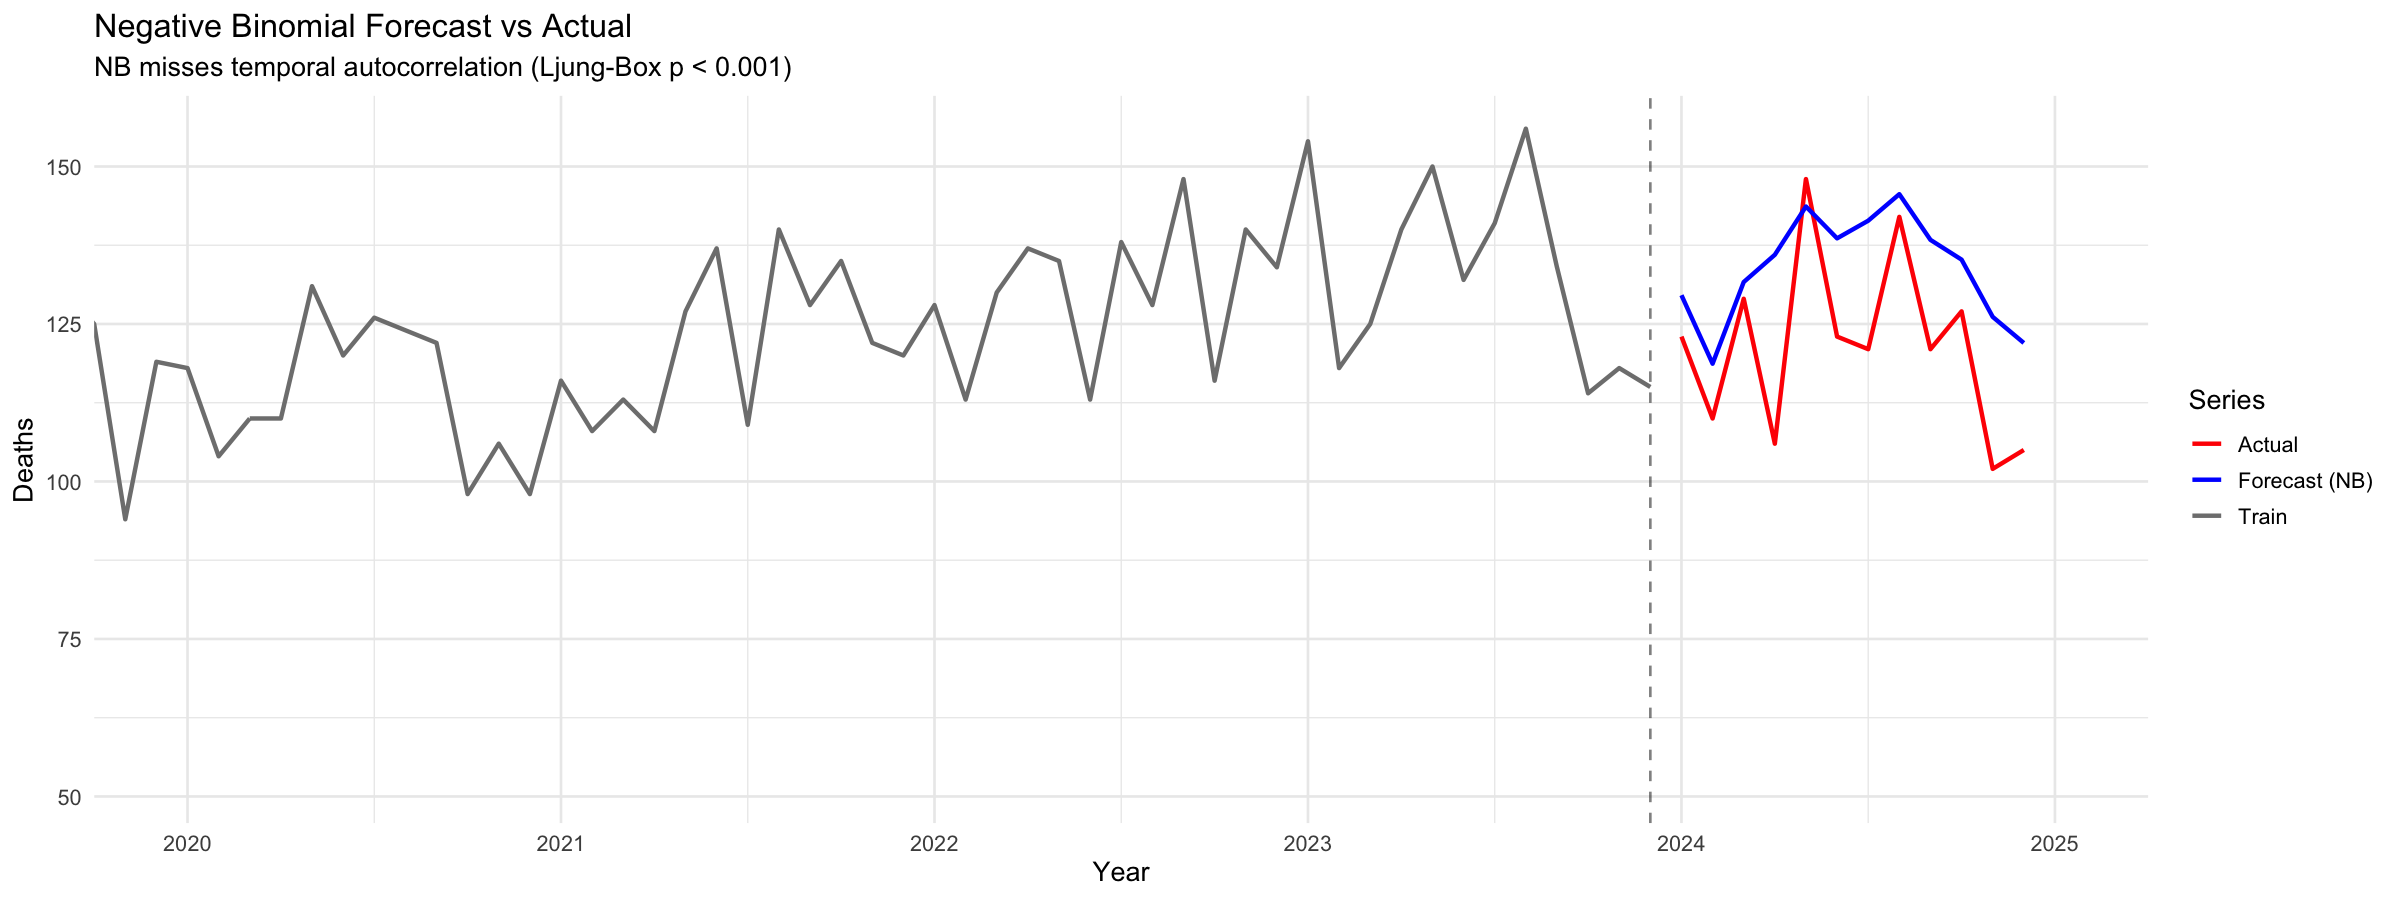

In [13]:
# NB Forecast vs Actual

options(repr.plot.width = 16, repr.plot.height = 6)

to_df <- function(x, name) {
  data.frame(Year = as.numeric(time(x)), Deaths = as.numeric(x), Series = name)
}

nb_pred_ts <- ts(nb_pred, start = start(holdout_ts), frequency = 12)
po_pred_ts <- ts(po_pred, start = start(holdout_ts), frequency = 12)
cut_year   <- as.numeric(end(train_ts)[1] + (end(train_ts)[2] - 1) / 12)

bind_rows(to_df(train_ts, "Train"), to_df(nb_pred_ts, "Forecast (NB)"),
          to_df(holdout_ts, "Actual")) %>%
  ggplot(aes(x = Year, y = Deaths, color = Series)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = cut_year, linetype = "dashed", alpha = 0.5) +
  coord_cartesian(xlim = c(2020, 2025)) +
  scale_color_manual(values = c("Train" = "grey50", "Forecast (NB)" = "blue", "Actual" = "red")) +
  labs(title = "Negative Binomial Forecast vs Actual",
       subtitle = "NB misses temporal autocorrelation (Ljung-Box p < 0.001)",
       x = "Year", y = "Deaths")

---
# 04 Modeling: Damped Holt-Winters (ETS)

In [14]:
# DAMPED MULTIPLICATIVE HOLT-WINTERS

hw_damped_model <- hw(train_ts, seasonal = "multiplicative", damped = TRUE,
                      h = length(holdout_ts))

cat("=== Damped Multiplicative Holt-Winters ===\n")
summary(hw_damped_model)

params   <- hw_damped_model$model$par
alpha_hw <- params["alpha"]; beta_hw <- params["beta"]
gamma_hw <- params["gamma"]; phi_hw  <- params["phi"]

cat(sprintf("\nalpha = %.4f | beta = %.4f | gamma = %.4f | phi = %.4f\n",
            alpha_hw, beta_hw, gamma_hw, phi_hw))
cat("AICc:", round(hw_damped_model$model$aicc, 2), "\n")

=== Damped Multiplicative Holt-Winters ===



Forecast method: Damped Holt-Winters' multiplicative method

Model Information:
Damped Holt-Winters' multiplicative method 

Call:
hw(y = train_ts, h = length(holdout_ts), seasonal = "multiplicative", 
    damped = TRUE)

  Smoothing parameters:
    alpha = 0.1267 
    beta  = 5e-04 
    gamma = 1e-04 
    phi   = 0.9729 

  Initial states:
    l = 91.1306 
    b = 0.0792 
    s = 0.9075 0.9338 1.0089 1.0318 1.0887 1.0568
           1.0304 1.0763 1.02 0.9841 0.8862 0.9755

  sigma:  0.1137

     AIC     AICc      BIC 
3210.998 3213.432 3277.666 

Error measures:
                    ME     RMSE      MAE       MPE     MAPE      MASE        ACF1
Training set 0.8571645 11.18661 8.886591 -0.407774 8.823815 0.7021504 -0.04352753

Forecasts:
         Point Forecast     Lo 80    Hi 80     Lo 95    Hi 95
Jan 2024       127.3551 108.78994 145.9202  98.96214 155.7480
Feb 2024       115.7182  98.71184 132.7245  89.70924 141.7271
Mar 2024       128.5291 109.48741 147.5707  99.40736 157.6508
Apr 20


alpha = 0.1267 | beta = 0.0005 | gamma = 0.0001 | phi = 0.9729
AICc: 3213.43 


In [15]:
# DAMPED HW: HOLDOUT EVALUATION

hw_damped_forecast <- forecast(hw_damped_model, h = length(holdout_ts))
hw_pred   <- as.numeric(hw_damped_forecast$mean)
hw_actual <- as.numeric(holdout_ts)
hw_error  <- hw_actual - hw_pred
hw_rmse   <- sqrt(mean(hw_error^2))
hw_mape   <- mean(abs(hw_error / hw_actual)) * 100

hw_lb <- Box.test(residuals(hw_damped_model), lag = 24, type = "Ljung-Box")

cat("RMSE:", round(hw_rmse, 2), "| MAPE:", round(hw_mape, 2), "%\n")
cat(sprintf("Ljung-Box p = %.4f  %s\n", hw_lb$p.value,
            ifelse(hw_lb$p.value > 0.05, "-> no significant autocorrelation", "-> autocorrelation")))

RMSE: 13.17 | MAPE: 9.3 %
Ljung-Box p = 0.6044  -> no significant autocorrelation


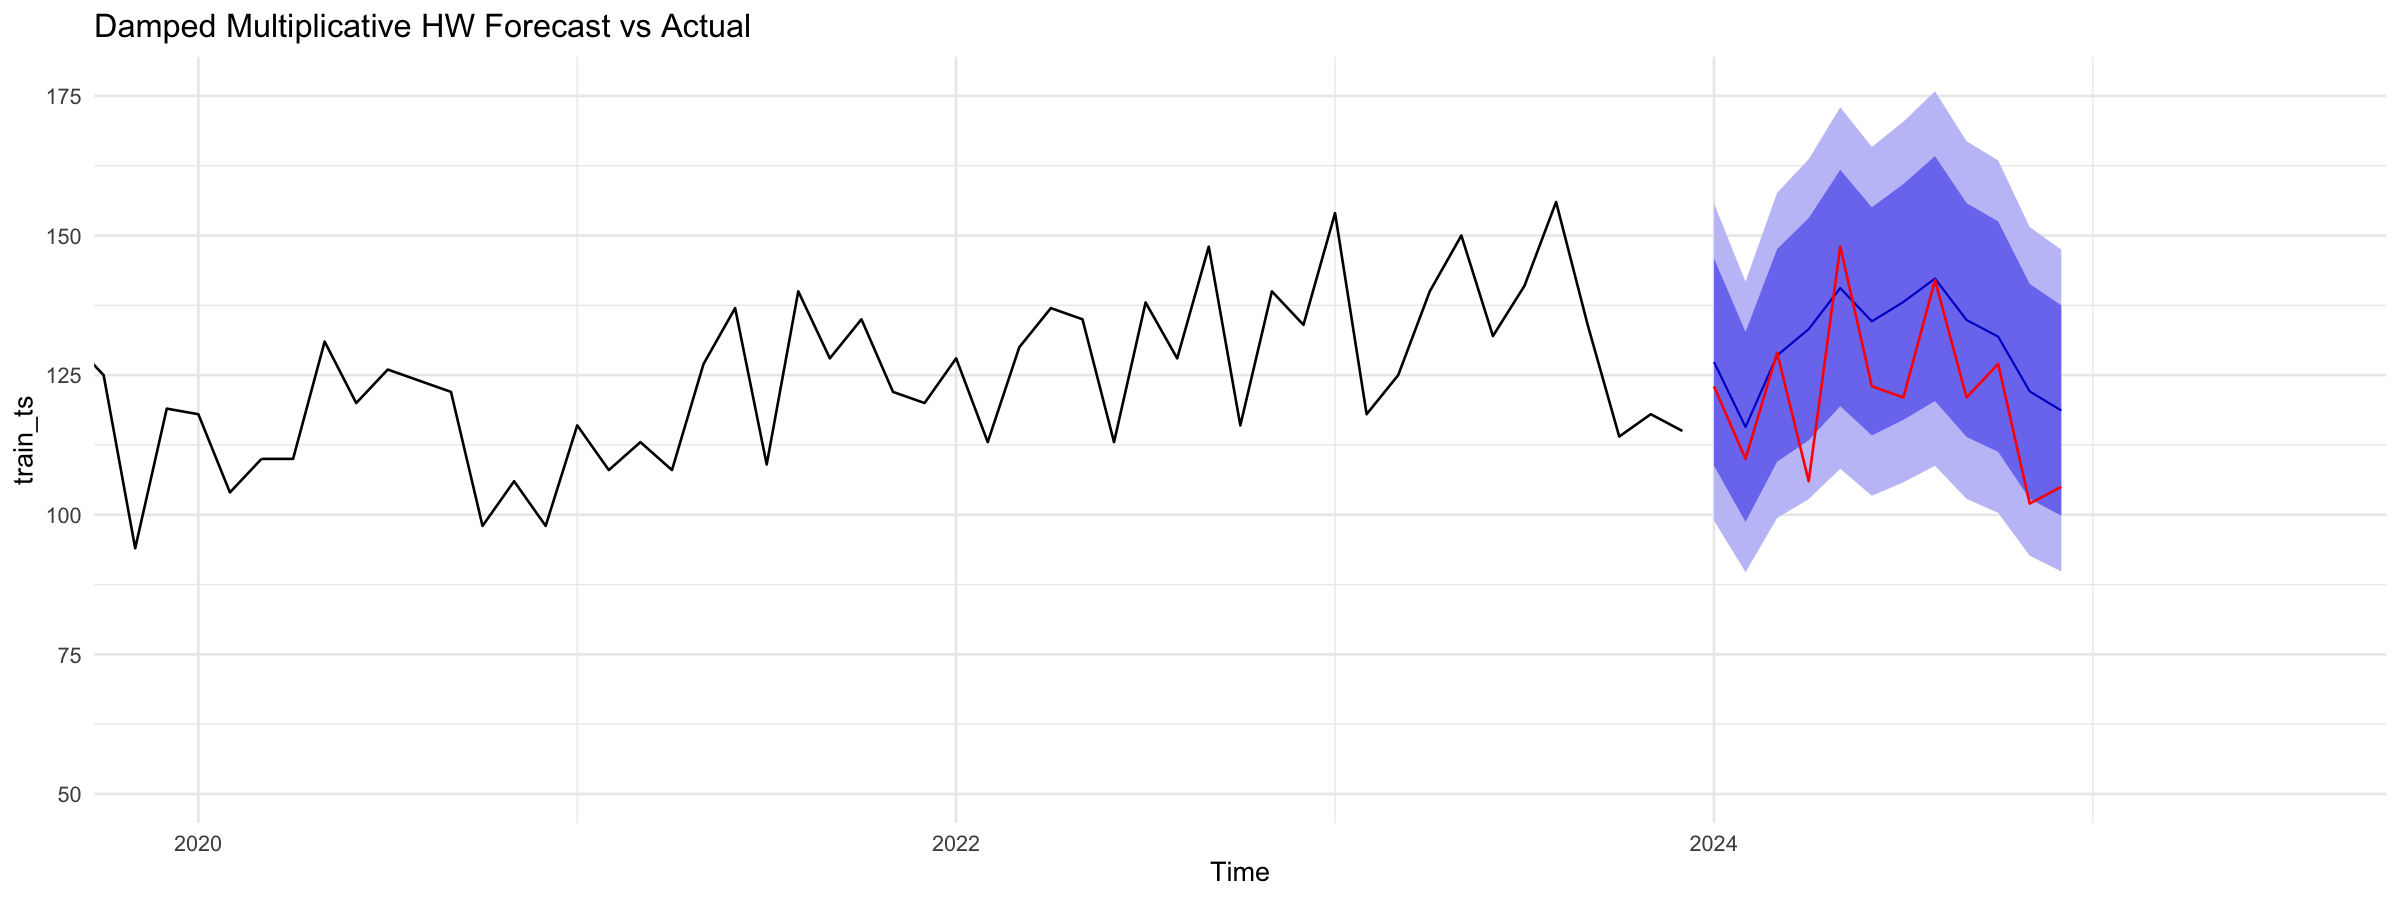

In [16]:
# Damped HW: Forecast Plot + Residual Diagnostics

options(repr.plot.width = 16, repr.plot.height = 6)
autoplot(hw_damped_model) +
  autolayer(holdout_ts, series = "Actual (2024)", color = "red") +
  ggtitle("Damped Multiplicative HW Forecast vs Actual") +
  coord_cartesian(xlim = c(2020, 2025.5))


	Ljung-Box test

data:  Residuals from Damped Holt-Winters' multiplicative method
Q* = 21.578, df = 24, p-value = 0.6044

Model df: 0.   Total lags used: 24



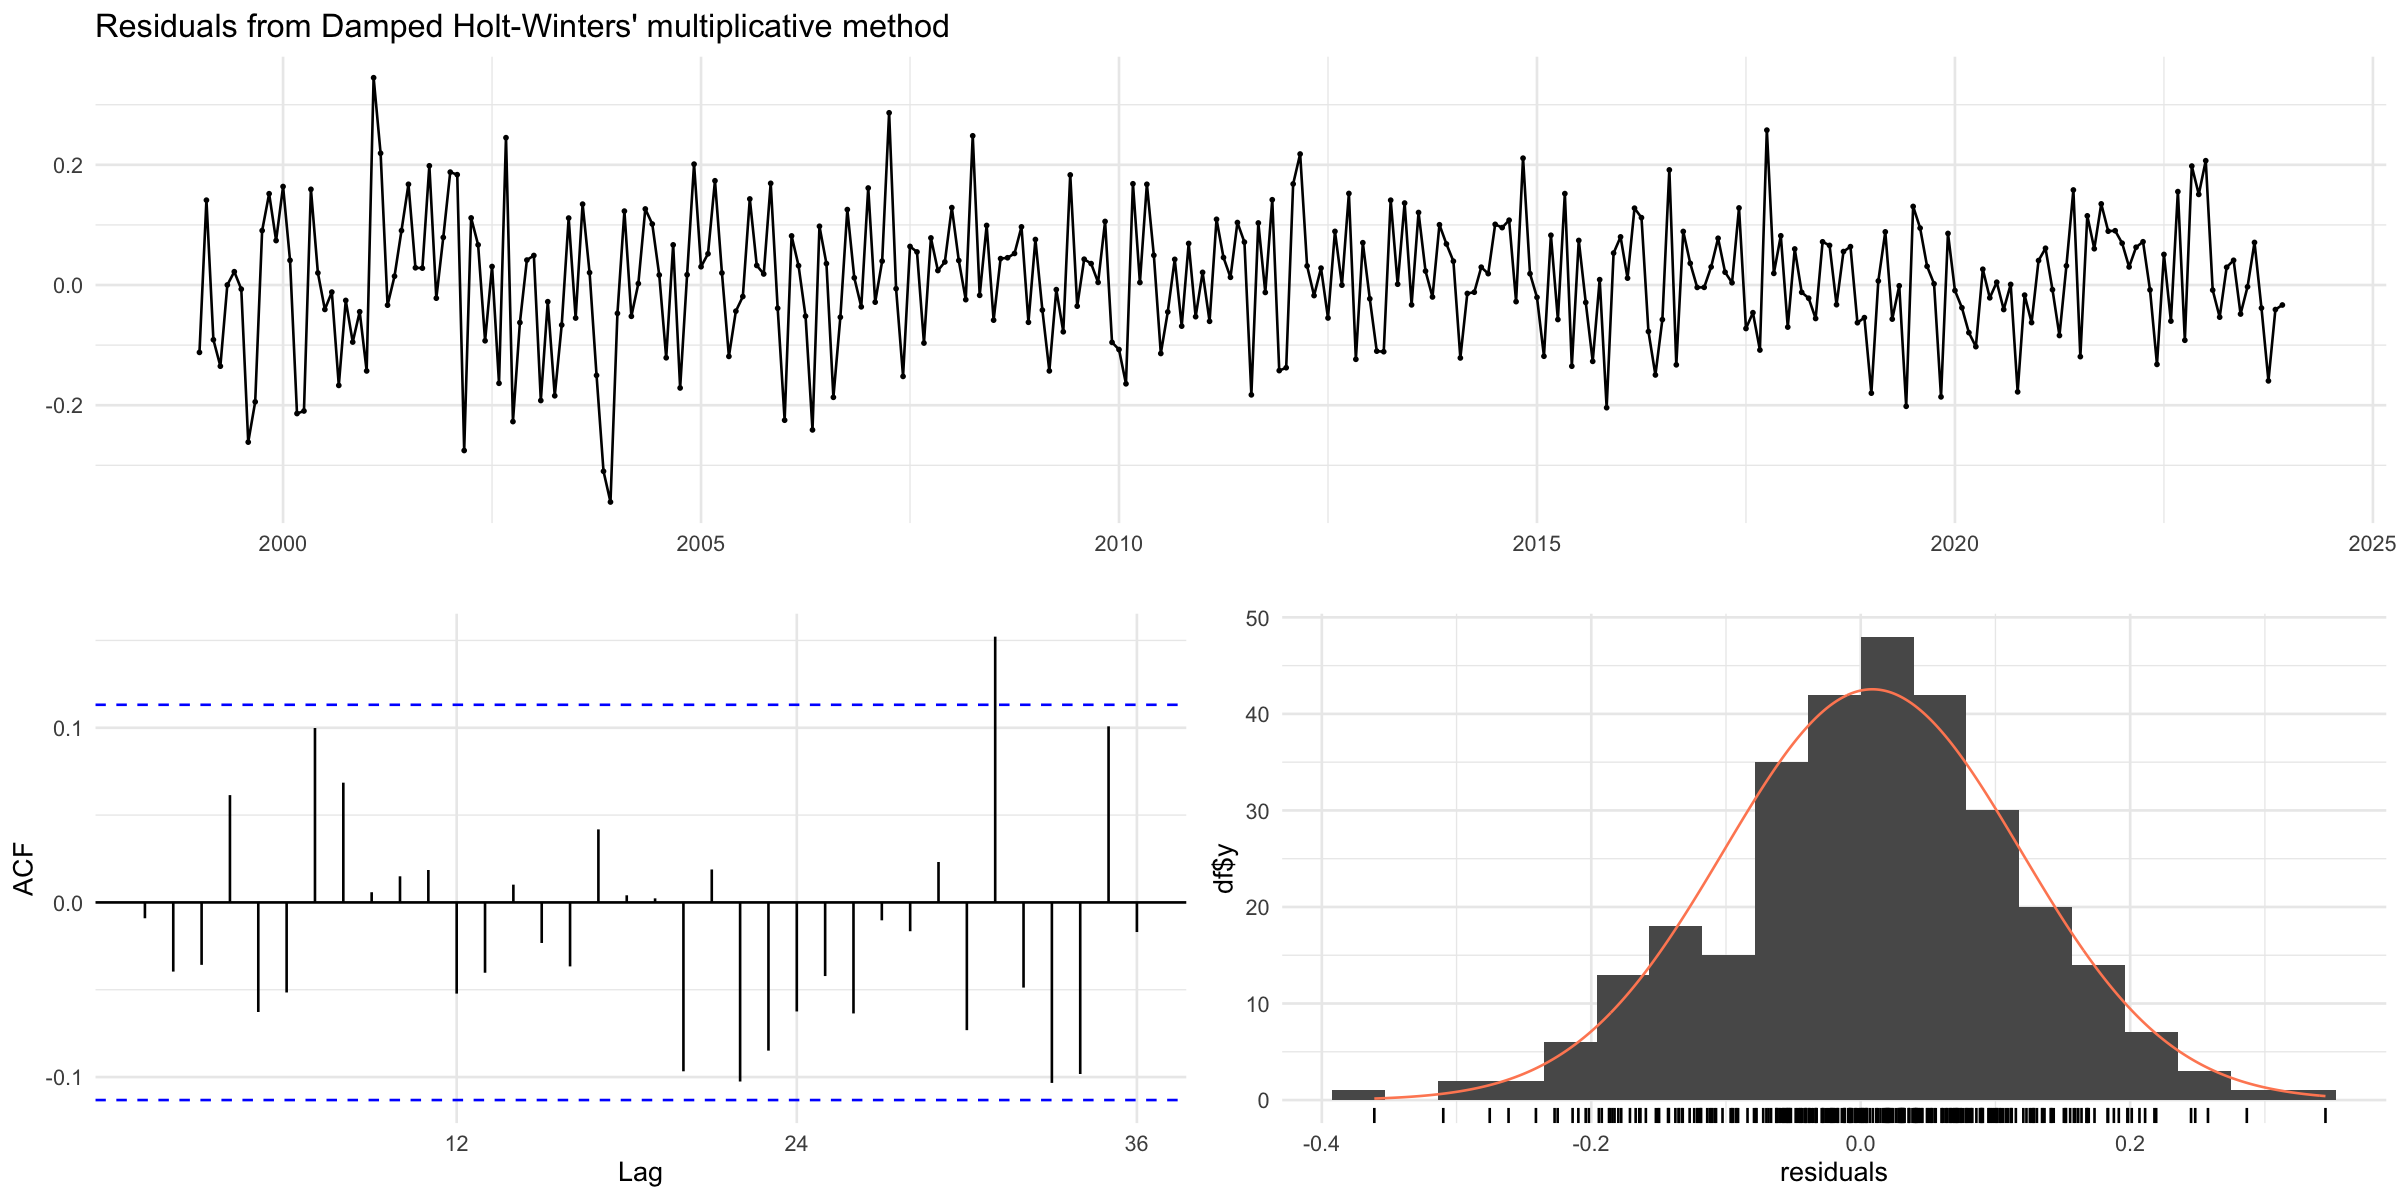

In [17]:
options(repr.plot.width = 16, repr.plot.height = 8)
checkresiduals(hw_damped_model)

---
# 05 Modeling: SARIMA

In [18]:
# SARIMA: ARIMA(4,0,0)(0,1,1)[12]

sarima_model <- Arima(
  train_ts,
  order    = c(4, 0, 0),
  seasonal = list(order = c(0, 1, 1), period = 12)
)

cat("=== SARIMA Model Summary ===\n")
summary(sarima_model)

cat("\nAIC:", round(sarima_model$aic, 2), "\n")
cat("AICc:", round(sarima_model$aicc, 2), "\n")
cat("BIC:", round(sarima_model$bic, 2), "\n")

=== SARIMA Model Summary ===


Series: train_ts 
ARIMA(4,0,0)(0,1,1)[12] 

Coefficients:
         ar1     ar2     ar3     ar4     sma1
      0.1748  0.1951  0.1374  0.2669  -0.8353
s.e.  0.0605  0.0602  0.0606  0.0613   0.0659

sigma^2 = 154.7:  log likelihood = -1139.42
AIC=2290.84   AICc=2291.14   BIC=2312.82

Training set error measures:
                 ME     RMSE     MAE      MPE     MAPE      MASE        ACF1
Training set 1.8138 12.08212 9.50328 0.476555 9.271112 0.7508764 -0.05037486


AIC: 2290.84 
AICc: 2291.14 
BIC: 2312.82 


=== SARIMA Holdout Evaluation ===


RMSE: 9.43 | MAPE: 6.64 %
Ljung-Box p: 0.248  -> no significant autocorrelation 


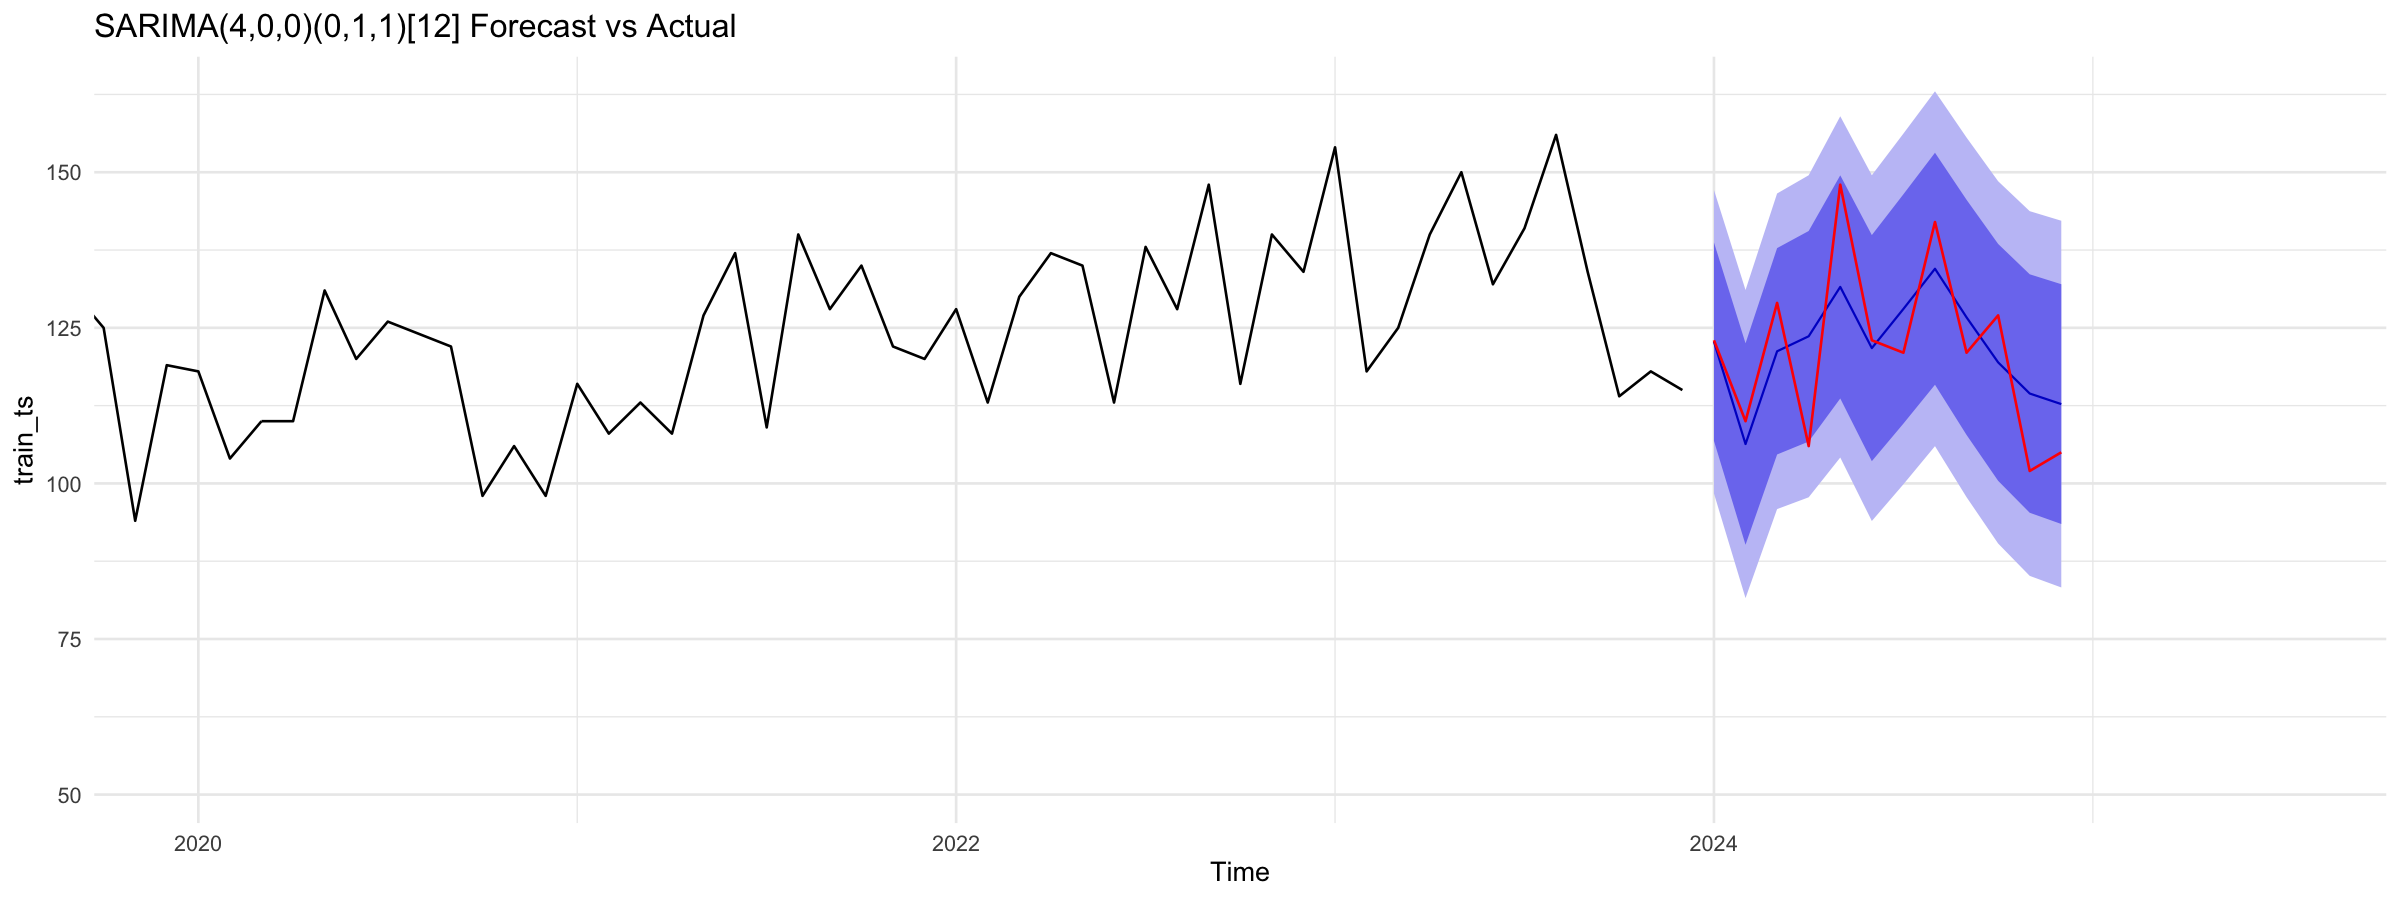

In [19]:
# SARIMA: HOLDOUT EVALUATION & FORECAST PLOT

options(repr.plot.width = 16, repr.plot.height = 6)

sarima_forecast <- forecast(sarima_model, h = length(holdout_ts))
sarima_pred     <- as.numeric(sarima_forecast$mean)
sarima_actual   <- as.numeric(holdout_ts)
sarima_error    <- sarima_actual - sarima_pred
sarima_rmse     <- sqrt(mean(sarima_error^2))
sarima_mape     <- mean(abs(sarima_error / sarima_actual)) * 100

sarima_lb <- Box.test(
  residuals(sarima_model),
  lag = 24,
  type = "Ljung-Box",
  fitdf = 5
)

cat("=== SARIMA Holdout Evaluation ===\n")
cat("RMSE:", round(sarima_rmse, 2), "| MAPE:", round(sarima_mape, 2), "%\n")
cat("Ljung-Box p:", round(sarima_lb$p.value, 4),
    ifelse(sarima_lb$p.value > 0.05, " -> no significant autocorrelation", " -> autocorrelation"), "\n")

autoplot(sarima_forecast) +
  autolayer(holdout_ts, series = "Actual (2024)", color = "red") +
  ggtitle("SARIMA(4,0,0)(0,1,1)[12] Forecast vs Actual") +
  coord_cartesian(xlim = c(2020, 2025.5))


	Ljung-Box test

data:  Residuals from ARIMA(4,0,0)(0,1,1)[12]
Q* = 22.762, df = 19, p-value = 0.248

Model df: 5.   Total lags used: 24



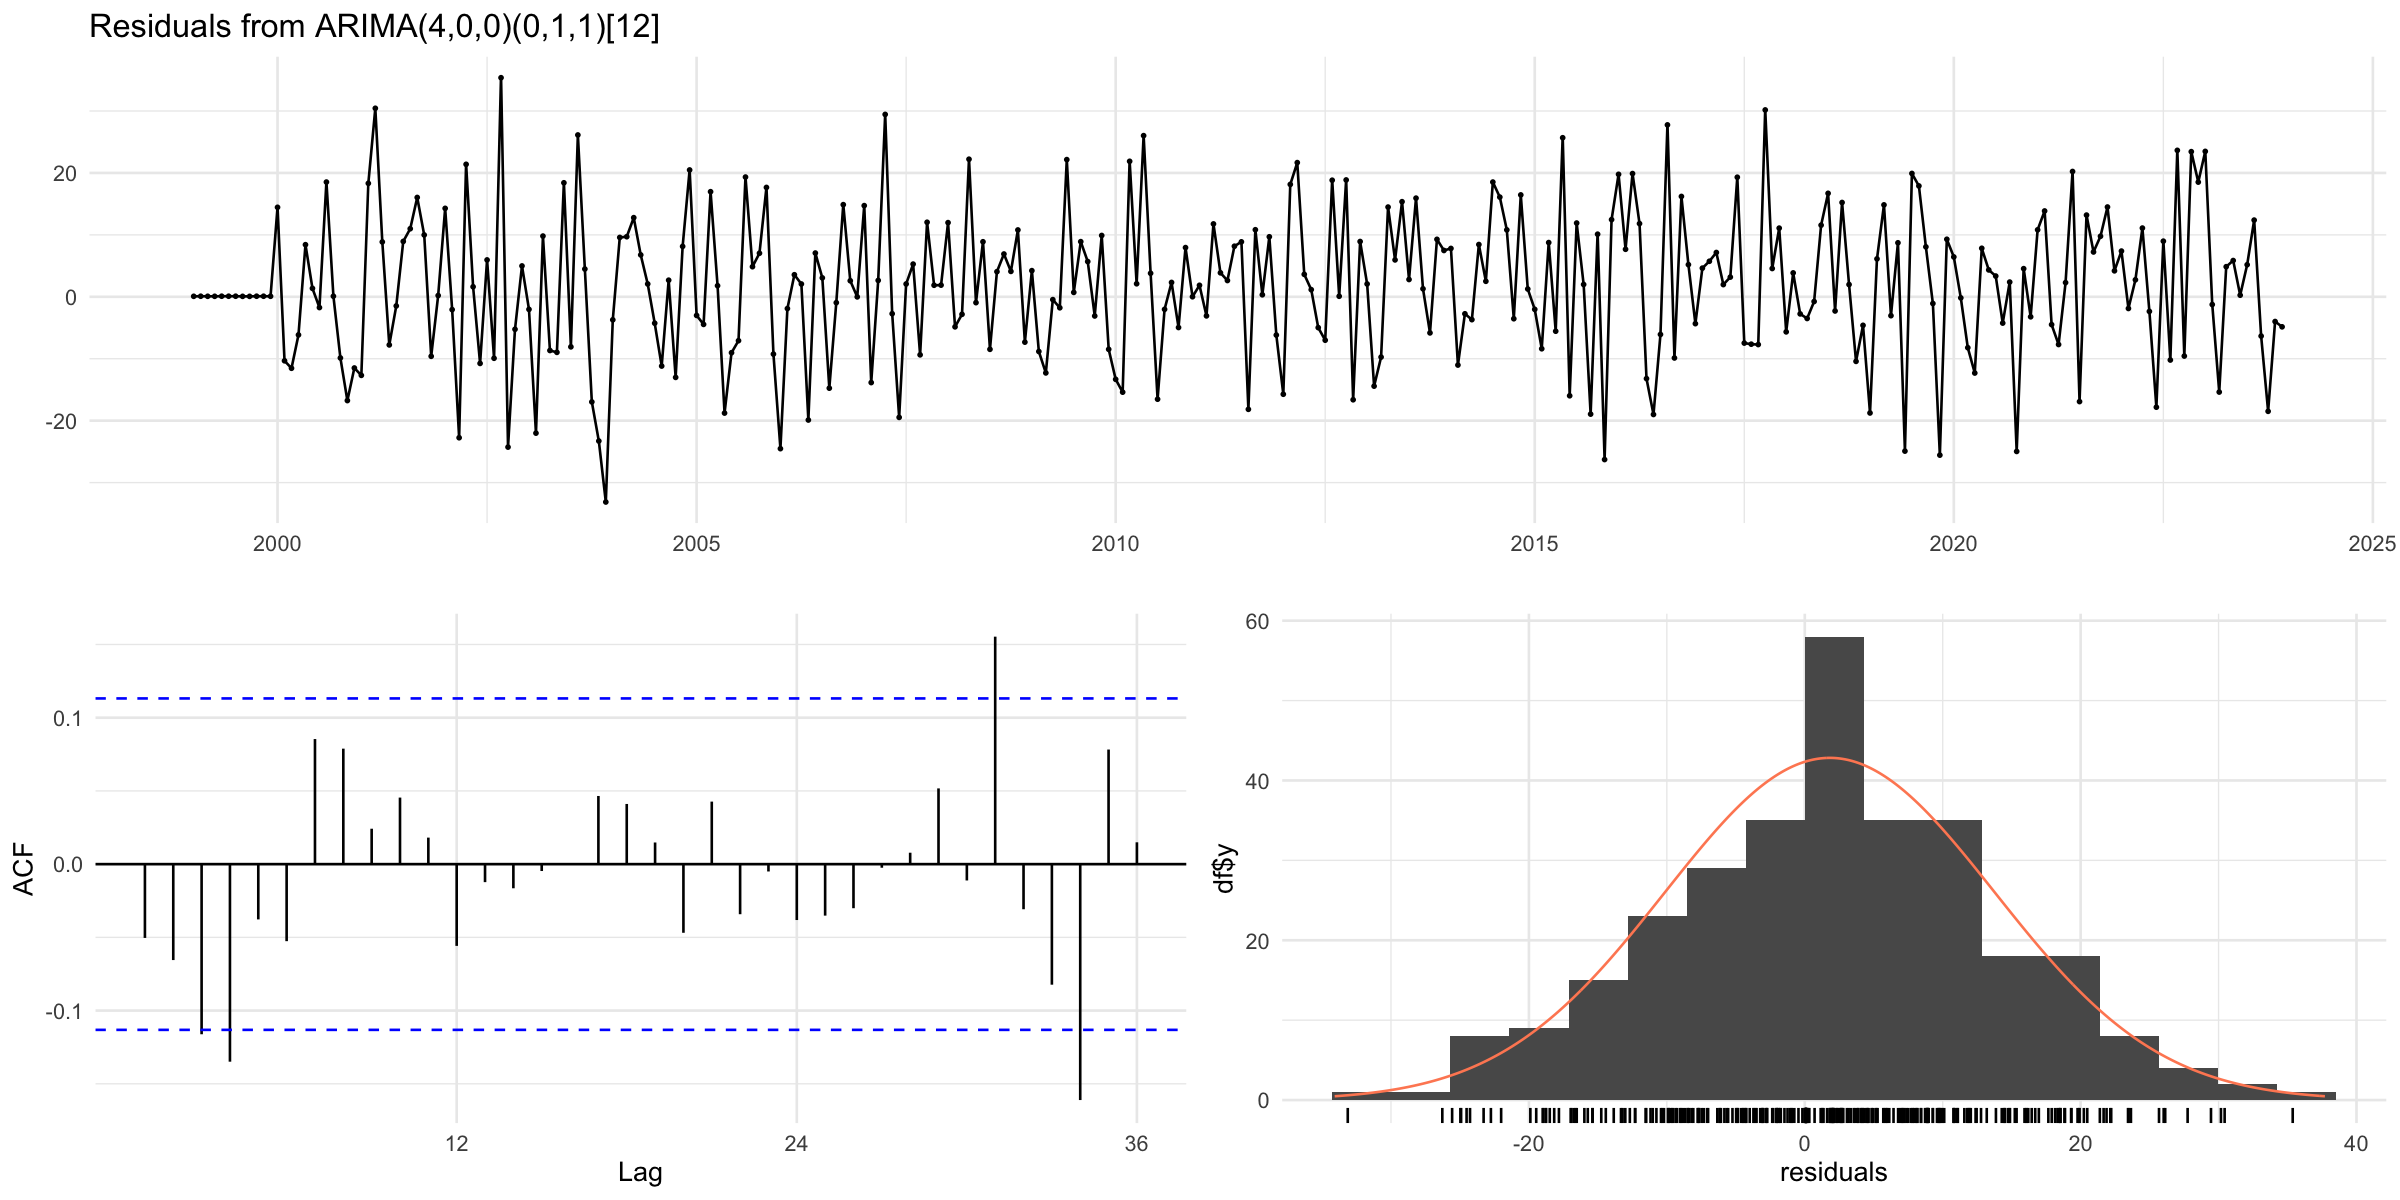

In [20]:
# SARIMA: RESIDUAL DIAGNOSTICS

options(repr.plot.width = 16, repr.plot.height = 8)
checkresiduals(sarima_model)

---
# 06 Model Evaluation & Comparison

In [21]:
# MODEL COMPARISON TABLE

snaive_model <- snaive(train_ts, h = length(holdout_ts))
snaive_acc   <- accuracy(snaive_model, holdout_ts)
snaive_rmse  <- snaive_acc["Test set", "RMSE"]
snaive_mape  <- snaive_acc["Test set", "MAPE"]

comparison_table <- data.frame(
  Model     = c("Seasonal Naive (Baseline)", "Poisson Regression",
                "Negative Binomial", "Damped HW (Multiplicative)",
                "SARIMA(4,0,0)(0,1,1)[12]"),
  AICc      = c(NA, round(aicc_po, 2), round(aicc_nb, 2),
                round(hw_damped_model$model$aicc, 2), round(sarima_model$aicc, 2)),
  RMSE      = c(round(snaive_rmse, 2), round(po_rmse, 2), round(nb_rmse, 2),
                round(hw_rmse, 2), round(sarima_rmse, 2)),
  MAPE      = c(round(snaive_mape, 2), round(po_mape, 2), round(nb_mape, 2),
                round(hw_mape, 2), round(sarima_mape, 2)),
  Ljung_Box = c("-", formatC(po_lb$p.value, format = "e", digits = 1),
                formatC(nb_lb$p.value, format = "e", digits = 1),
                round(hw_lb$p.value, 4), round(sarima_lb$p.value, 4)),
  Verdict   = c("Reference", "Autocorrelation", "Autocorrelation",
                "Good", "WINNER")
)

cat("=== Head-to-Head Model Comparison ===\n\n")
print(comparison_table, row.names = FALSE)

rmse_impr <- (1 - sarima_rmse / snaive_rmse) * 100
mape_impr <- (1 - sarima_mape / snaive_mape) * 100

cat(sprintf("\n-> %.0f%% RMSE improvement  (SARIMA %.2f vs Baseline %.2f)\n", rmse_impr, sarima_rmse, snaive_rmse))
cat(sprintf("-> %.0f%% MAPE improvement  (SARIMA %.2f%% vs Baseline %.2f%%)\n", mape_impr, sarima_mape, snaive_mape))
cat(sprintf("-> SARIMA vs Damped HW:  RMSE %.2f vs %.2f  |  MAPE %.2f%% vs %.2f%%\n",
            sarima_rmse, hw_rmse, sarima_mape, hw_mape))

=== Head-to-Head Model Comparison ===

                      Model    AICc  RMSE  MAPE Ljung_Box         Verdict
  Seasonal Naive (Baseline)      NA 17.25 12.41         -       Reference
         Poisson Regression 2354.31 15.71 11.62   1.1e-08 Autocorrelation
          Negative Binomial 2349.51 15.69 11.60   1.1e-08 Autocorrelation
 Damped HW (Multiplicative) 3213.43 13.17  9.30    0.6044            Good
   SARIMA(4,0,0)(0,1,1)[12] 2291.14  9.43  6.64     0.248          WINNER



-> 45% RMSE improvement  (SARIMA 9.43 vs Baseline 17.25)
-> 47% MAPE improvement  (SARIMA 6.64% vs Baseline 12.41%)
-> SARIMA vs Damped HW:  RMSE 9.43 vs 13.17  |  MAPE 6.64% vs 9.30%


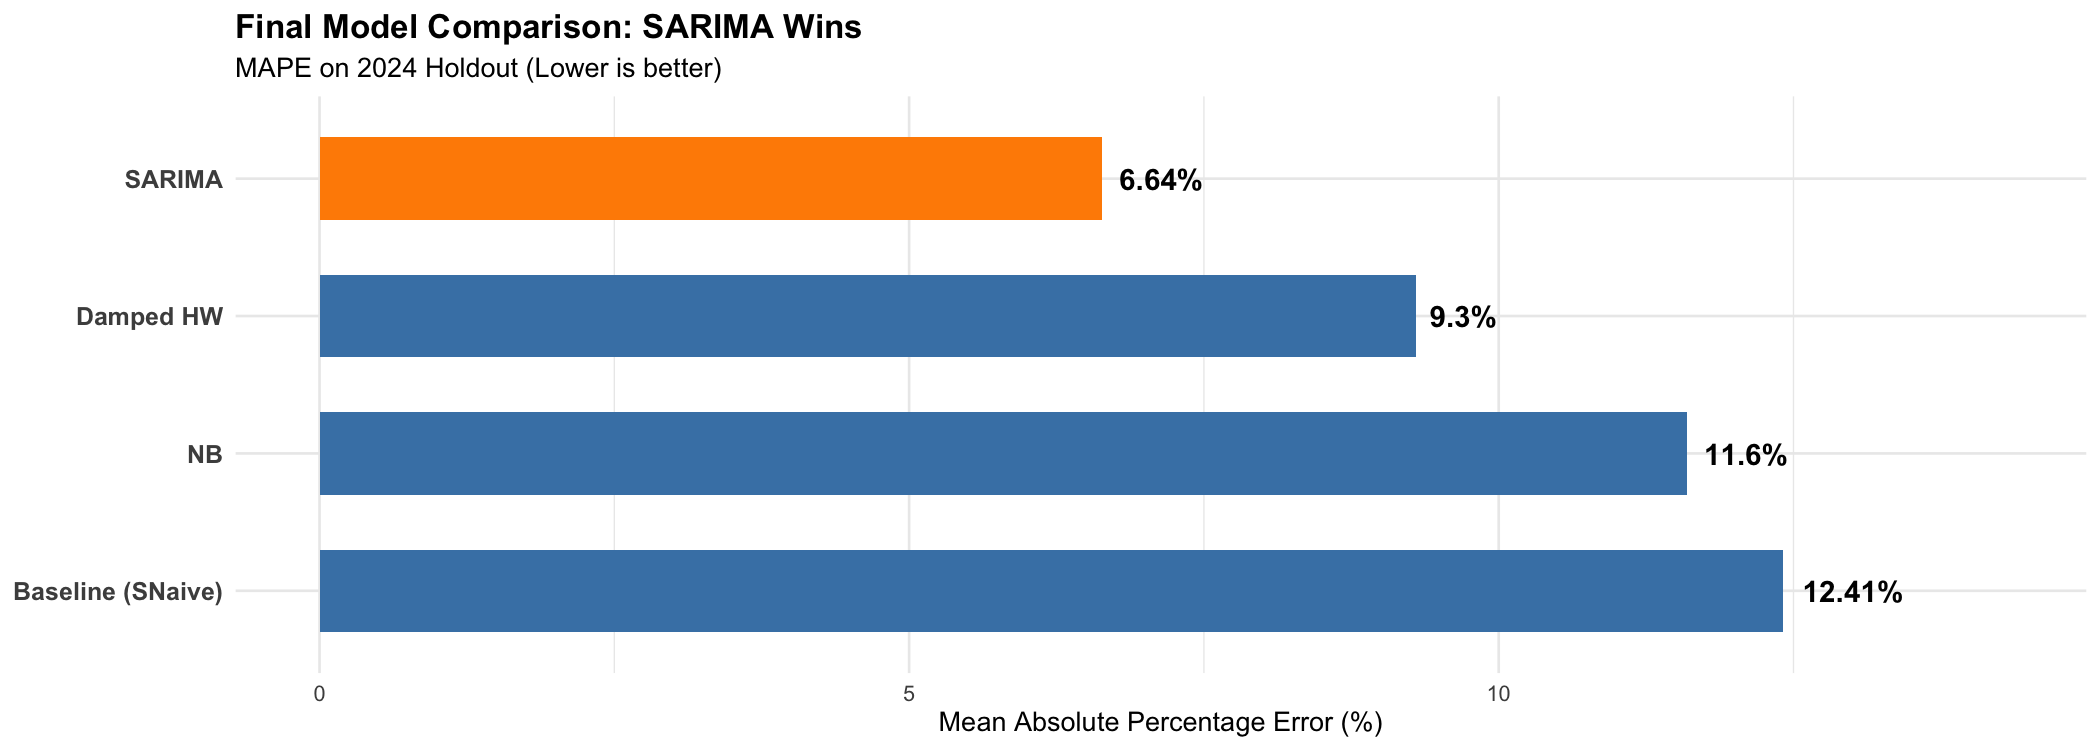

In [22]:
# MAPE Comparison Bar Chart

options(repr.plot.width = 14, repr.plot.height = 5)

mape_df <- data.frame(
  Model = c("Baseline (SNaive)", "NB", "Damped HW", "SARIMA"),
  MAPE  = c(round(snaive_mape, 2), round(nb_mape, 2), round(hw_mape, 2), round(sarima_mape, 2))
)
mape_df$Model <- factor(mape_df$Model, levels = mape_df$Model[order(mape_df$MAPE, decreasing = TRUE)])
bar_colors <- ifelse(mape_df$Model == "SARIMA", "darkorange", "steelblue")

ggplot(mape_df, aes(x = Model, y = MAPE)) +
  geom_bar(stat = "identity", width = 0.6, fill = bar_colors) +
  geom_text(aes(label = paste0(MAPE, "%")), hjust = -0.2, fontface = "bold", size = 5) +
  coord_flip() +
  labs(title = "Final Model Comparison: SARIMA Wins",
       subtitle = "MAPE on 2024 Holdout (Lower is better)",
       y = "Mean Absolute Percentage Error (%)", x = NULL) +
  theme(legend.position = "none", plot.title = element_text(face = "bold", size = 16),
        axis.text.y = element_text(size = 12, face = "bold")) +
  ylim(0, max(mape_df$MAPE) * 1.15)

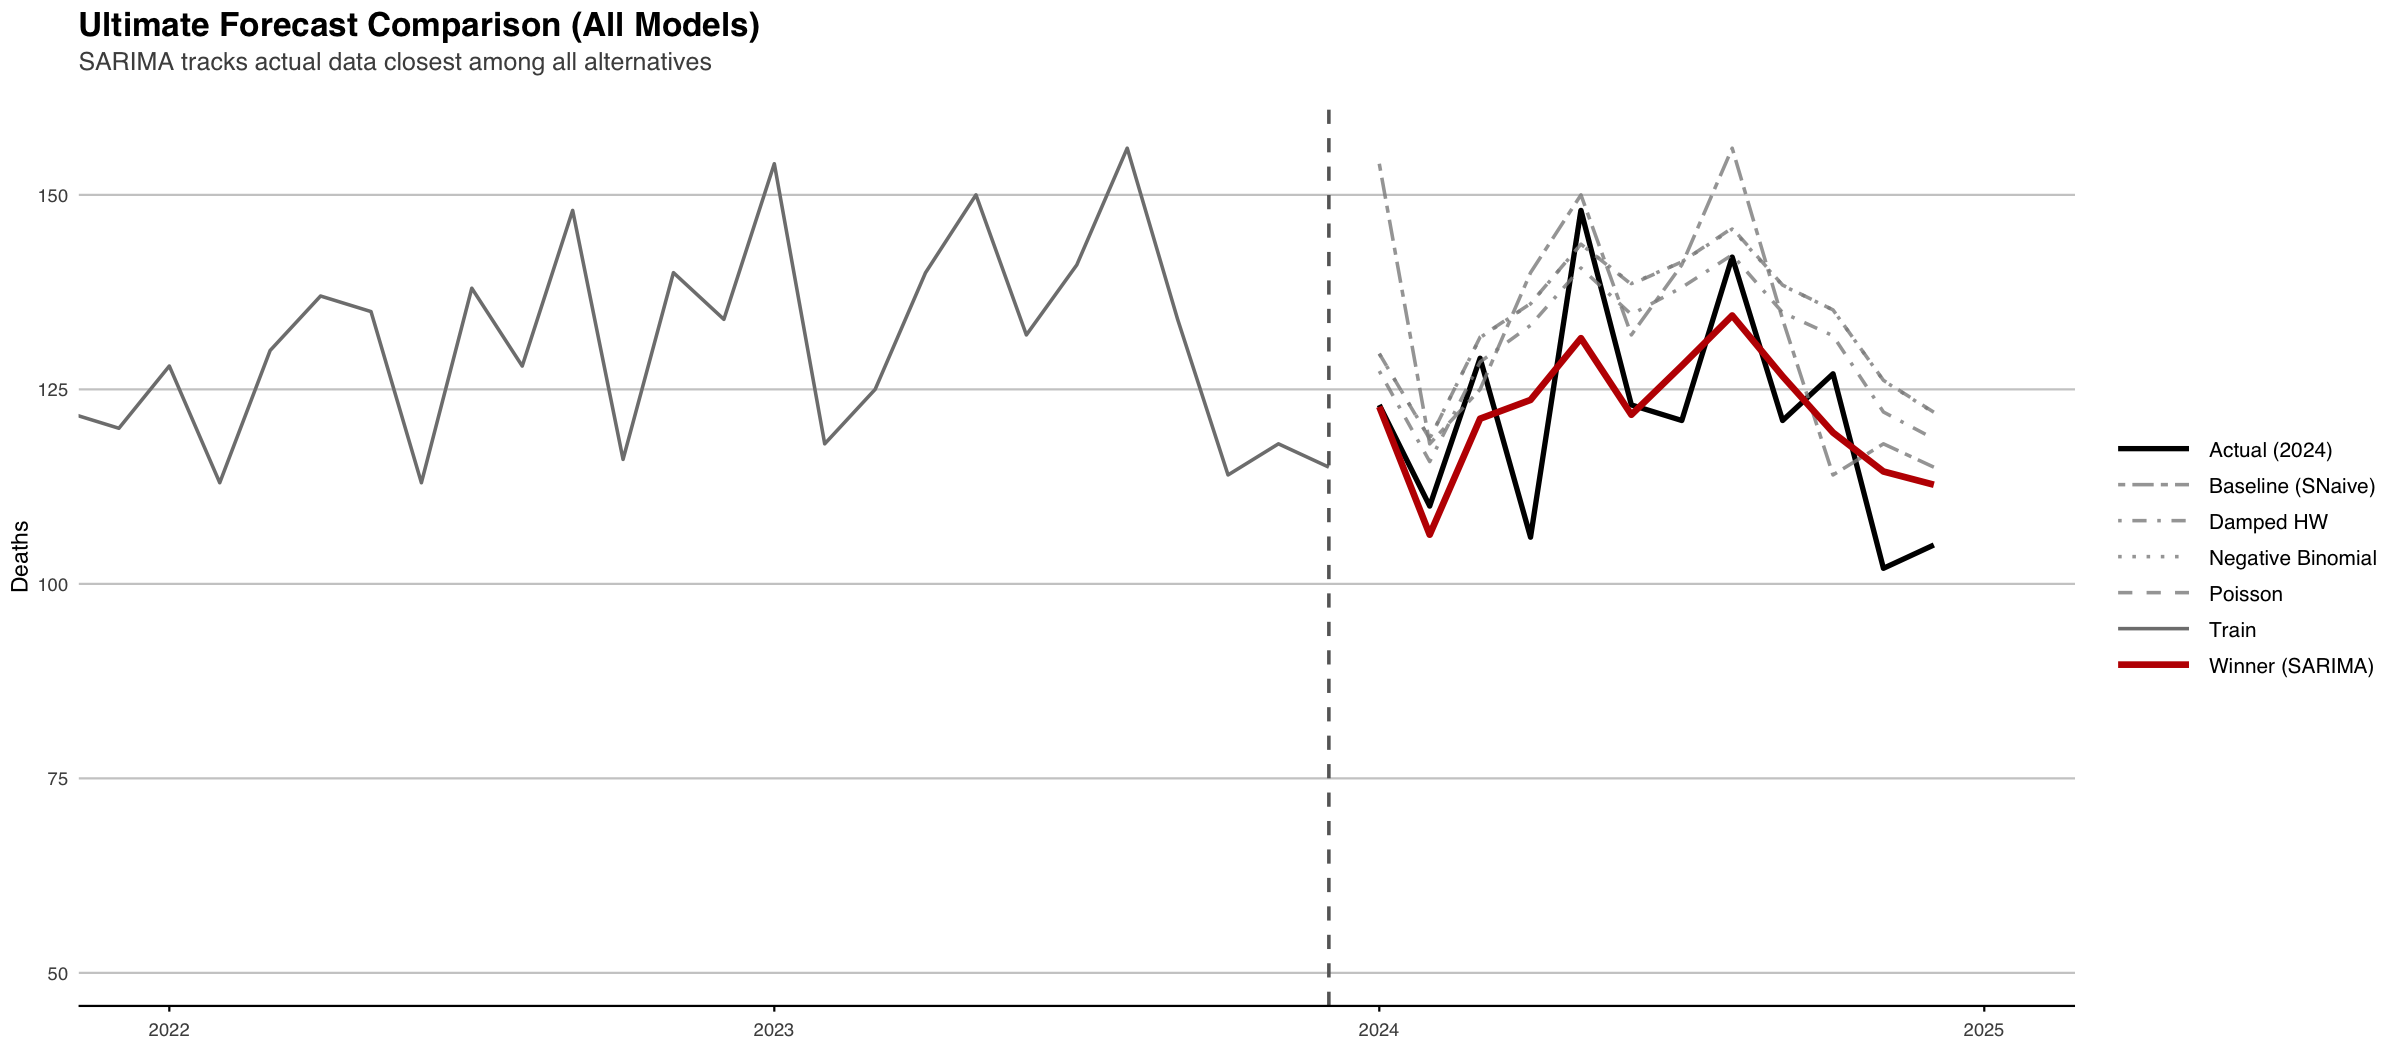

In [23]:
# ALL MODELS OVERLAY

options(repr.plot.width = 16, repr.plot.height = 7)

sarima_pred_ts <- ts(sarima_pred, start = start(holdout_ts), frequency = 12)
hw_pred_ts     <- hw_damped_forecast$mean

ultimate_df <- bind_rows(
  to_df(train_ts, "Train"), to_df(holdout_ts, "Actual (2024)"),
  to_df(snaive_model$mean, "Baseline (SNaive)"),
  to_df(po_pred_ts, "Poisson"), to_df(nb_pred_ts, "Negative Binomial"),
  to_df(hw_pred_ts, "Damped HW"), to_df(sarima_pred_ts, "Winner (SARIMA)")
)



ggplot(ultimate_df, aes(x = Year, y = Deaths, 
                        color = Series, linetype = Series, 
                        linewidth = Series, alpha = Series)) +
  geom_line() +

  geom_vline(xintercept = cut_year, linetype = "dashed", color = "grey40", linewidth = 0.8) +
  coord_cartesian(xlim = c(2022, 2025)) +
  
  scale_color_manual(values = c(
    "Train" = "grey50", 
    "Actual (2024)" = "black",        
    "Baseline (SNaive)" = "grey55", 
    "Poisson" = "grey55", 
    "Negative Binomial" = "grey55",
    "Damped HW" = "grey55", 
    "Winner (SARIMA)" = "#C00000"       
  )) +
  
  scale_linetype_manual(values = c(
    "Train" = "solid", 
    "Actual (2024)" = "solid", 
    "Baseline (SNaive)" = "twodash",
    "Poisson" = "dashed", 
    "Negative Binomial" = "dotted",
    "Damped HW" = "dotdash", 
    "Winner (SARIMA)" = "solid"
  )) +
  
  scale_linewidth_manual(values = c(
    "Train" = 0.8, 
    "Actual (2024)" = 1.2, 
    "Baseline (SNaive)" = 0.8,
    "Poisson" = 0.8, 
    "Negative Binomial" = 0.8,
    "Damped HW" = 0.8, 
    "Winner (SARIMA)" = 1.5
  )) +
  
  scale_alpha_manual(values = c(
    "Train" = 1.0, 
    "Actual (2024)" = 1.0, 
    "Baseline (SNaive)" = 0.8,
    "Poisson" = 0.8, 
    "Negative Binomial" = 0.8,
    "Damped HW" = 0.8, 
    "Winner (SARIMA)" = 1.0
  )) +
  
  labs(
    title = "Ultimate Forecast Comparison (All Models)",
    subtitle = "SARIMA tracks actual data closest among all alternatives",
    x = NULL, 
    y = "Deaths"
  ) +
  
  theme_minimal(base_family = "sans") +
  theme(
    plot.title = element_text(face = "bold", size = 16, margin = margin(b = 5)),
    plot.subtitle = element_text(size = 12, color = "grey30", margin = margin(b = 15)),
    axis.line.x = element_line(color = "black", linewidth = 0.5),
    axis.ticks.x = element_line(color = "black"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_line(color = "grey80", linewidth = 0.5),
    panel.grid.minor.y = element_blank(),
    legend.position = "right", 
    legend.title = element_blank(),
    legend.key.width = unit(1.5, "cm"),
    legend.text = element_text(size = 10)
  )

---
# 07 Advanced Validation: SARIMA (Winner)

Running SARIMA Walk-Forward CV (~2-3 min)...
CV RMSE: 13.55  (vs holdout 9.43)
CV MAPE: 10.44%  (vs holdout 6.64%)


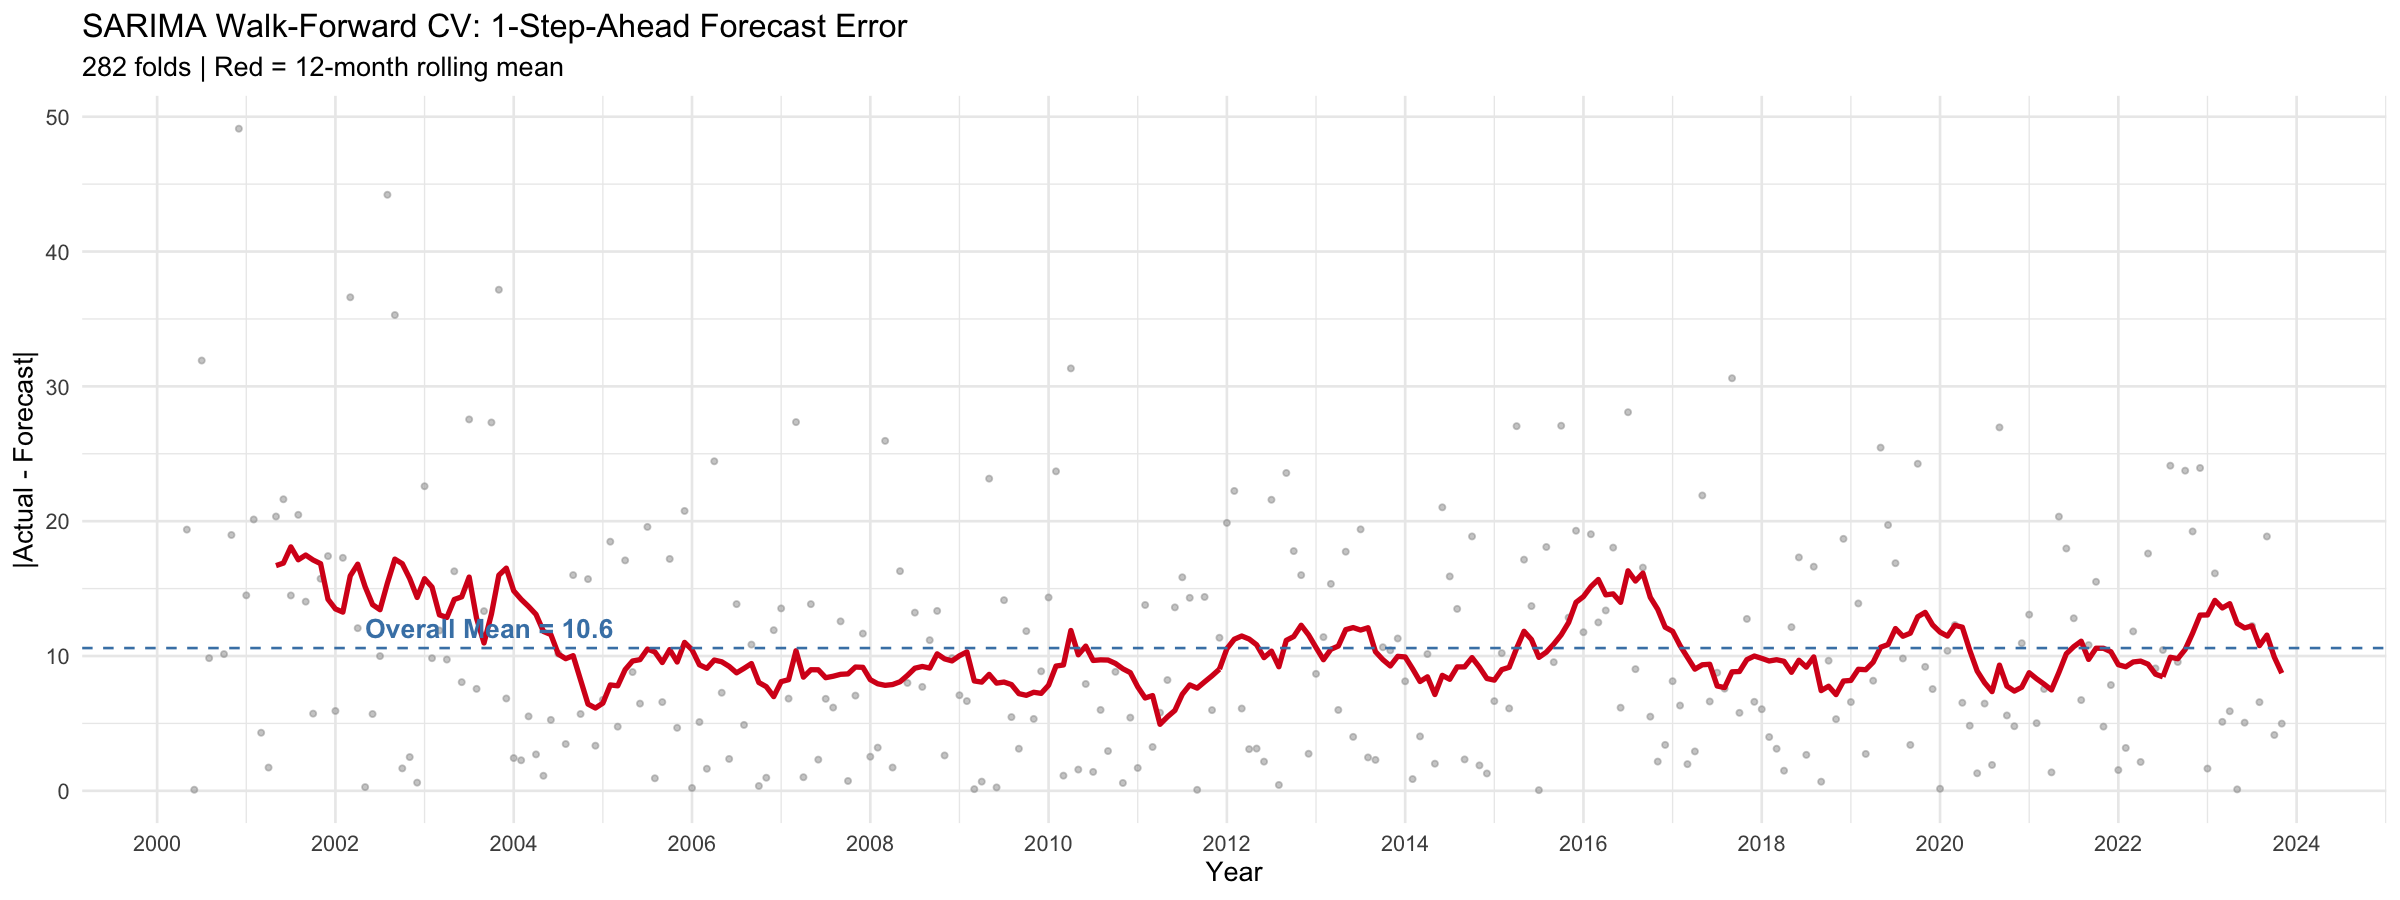

In [24]:

# WALK-FORWARD CROSS-VALIDATION: SARIMA


options(repr.plot.width = 16, repr.plot.height = 6)

f_sarima <- function(x, h) {
  forecast(Arima(x, order = c(4, 0, 0),
                 seasonal = list(order = c(0, 1, 1), period = 12)), h = h)
}

cat("Running SARIMA Walk-Forward CV (~2-3 min)...\n")
cv_errors_sarima <- tsCV(train_ts, f_sarima, h = 1)

tscv_rmse <- sqrt(mean(cv_errors_sarima^2, na.rm = TRUE))
tscv_mape <- mean(abs(cv_errors_sarima / train_ts), na.rm = TRUE) * 100

cat(sprintf("CV RMSE: %.2f  (vs holdout %.2f)\n", tscv_rmse, sarima_rmse))
cat(sprintf("CV MAPE: %.2f%%  (vs holdout %.2f%%)\n", tscv_mape, sarima_mape))

cv_df <- data.frame(time_index = as.numeric(time(train_ts)),
                    abs_error  = abs(as.numeric(cv_errors_sarima)))
cv_df <- cv_df[!is.na(cv_df$abs_error), ]
cv_df$rolling <- rollmean(cv_df$abs_error, k = 12, fill = NA, align = "right")
overall_mean <- mean(cv_df$abs_error, na.rm = TRUE)

ggplot(cv_df, aes(x = time_index)) +
  geom_point(aes(y = abs_error), color = "grey60", size = 1, alpha = 0.5) +
  geom_line(aes(y = rolling), color = "#D7191C", linewidth = 1.2, na.rm = TRUE) +
  geom_hline(yintercept = overall_mean, linetype = "dashed", color = "steelblue") +
  annotate("text", x = min(cv_df$time_index) + 2, y = overall_mean + 1.5,
           label = paste0("Overall Mean = ", round(overall_mean, 1)),
           color = "steelblue", size = 4.5, hjust = 0, fontface = "bold") +
  labs(title = "SARIMA Walk-Forward CV: 1-Step-Ahead Forecast Error",
       subtitle = paste0(nrow(cv_df), " folds | Red = 12-month rolling mean"),
       x = "Year", y = "|Actual - Forecast|") +
  scale_x_continuous(breaks = seq(2000, 2024, 2))

80% PI Coverage: 92%
95% PI Coverage: 100%


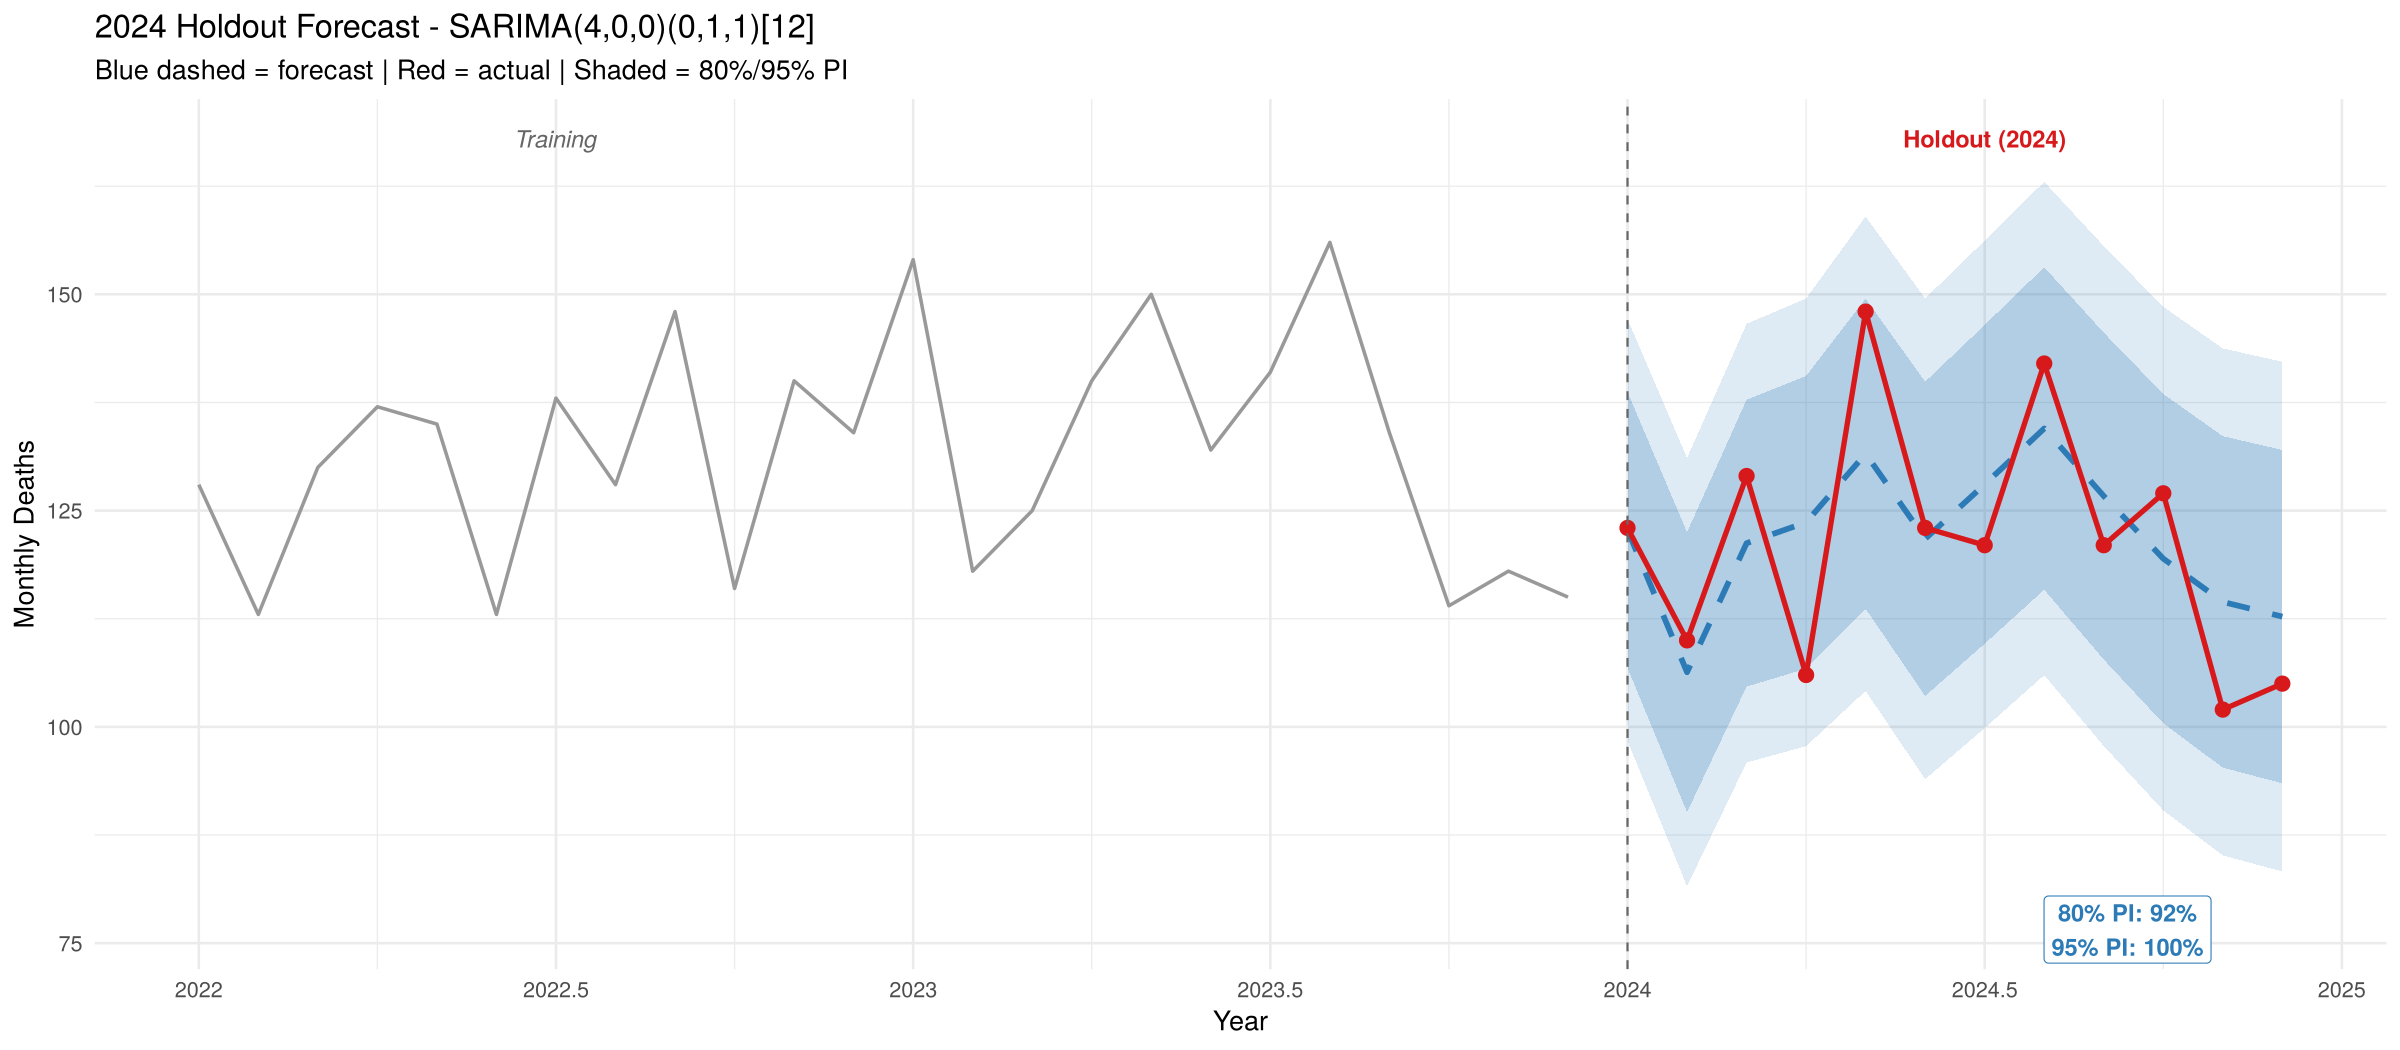

In [25]:
# PREDICTION INTERVAL COVERAGE: SARIMA

options(repr.plot.width = 16, repr.plot.height = 7)
actual <- as.numeric(holdout_ts)

lo80_s <- as.numeric(sarima_forecast$lower[, 1])
hi80_s <- as.numeric(sarima_forecast$upper[, 1])
lo95_s <- as.numeric(sarima_forecast$lower[, 2])
hi95_s <- as.numeric(sarima_forecast$upper[, 2])

cov80 <- mean(actual >= lo80_s & actual <= hi80_s) * 100
cov95 <- mean(actual >= lo95_s & actual <= hi95_s) * 100
cat(sprintf("80%% PI Coverage: %.0f%%\n95%% PI Coverage: %.0f%%\n", cov80, cov95))

fc_time <- as.numeric(time(sarima_forecast$mean))
tr_rec  <- window(train_ts, start = c(2022, 1))

fc_df <- data.frame(t = fc_time, actual = actual, forecast = sarima_pred,
                    lo80 = lo80_s, hi80 = hi80_s, lo95 = lo95_s, hi95 = hi95_s)
tr_df <- data.frame(t = as.numeric(time(tr_rec)), deaths = as.numeric(tr_rec))

ggplot() +
  geom_line(data = tr_df, aes(x = t, y = deaths), color = "grey60", linewidth = 0.8) +
  geom_ribbon(data = fc_df, aes(x = t, ymin = lo95, ymax = hi95), fill = "#2C7BB6", alpha = 0.15) +
  geom_ribbon(data = fc_df, aes(x = t, ymin = lo80, ymax = hi80), fill = "#2C7BB6", alpha = 0.25) +
  geom_line(data = fc_df, aes(x = t, y = forecast), color = "#2C7BB6", linewidth = 1.3, linetype = "dashed") +
  geom_line(data = fc_df, aes(x = t, y = actual), color = "#D7191C", linewidth = 1.2) +
  geom_point(data = fc_df, aes(x = t, y = actual), color = "#D7191C", size = 3) +
  geom_vline(xintercept = 2024, linetype = "dashed", color = "grey40") +
  annotate("text", x = 2022.5, y = max(hi95_s) + 5, label = "Training", color = "grey40", size = 4, fontface = "italic") +
  annotate("text", x = 2024.5, y = max(hi95_s) + 5, label = "Holdout (2024)", color = "#D7191C", size = 4, fontface = "bold") +
  annotate("label", x = 2024.7, y = min(lo95_s) - 5,
           label = sprintf("80%% PI: %.0f%%\n95%% PI: %.0f%%", cov80, cov95),
           fill = "white", color = "#2C7BB6", size = 4, fontface = "bold") +
  labs(title = "2024 Holdout Forecast - SARIMA(4,0,0)(0,1,1)[12]",
       subtitle = "Blue dashed = forecast | Red = actual | Shaded = 80%/95% PI",
       x = "Year", y = "Monthly Deaths") +
  scale_x_continuous(breaks = seq(2022, 2025, 0.5),
                     labels = function(x) ifelse(x %% 1 == 0, as.character(as.integer(x)), format(x, nsmall = 1)))

---
# 08 Residual Diagnostics: SARIMA (Winner)

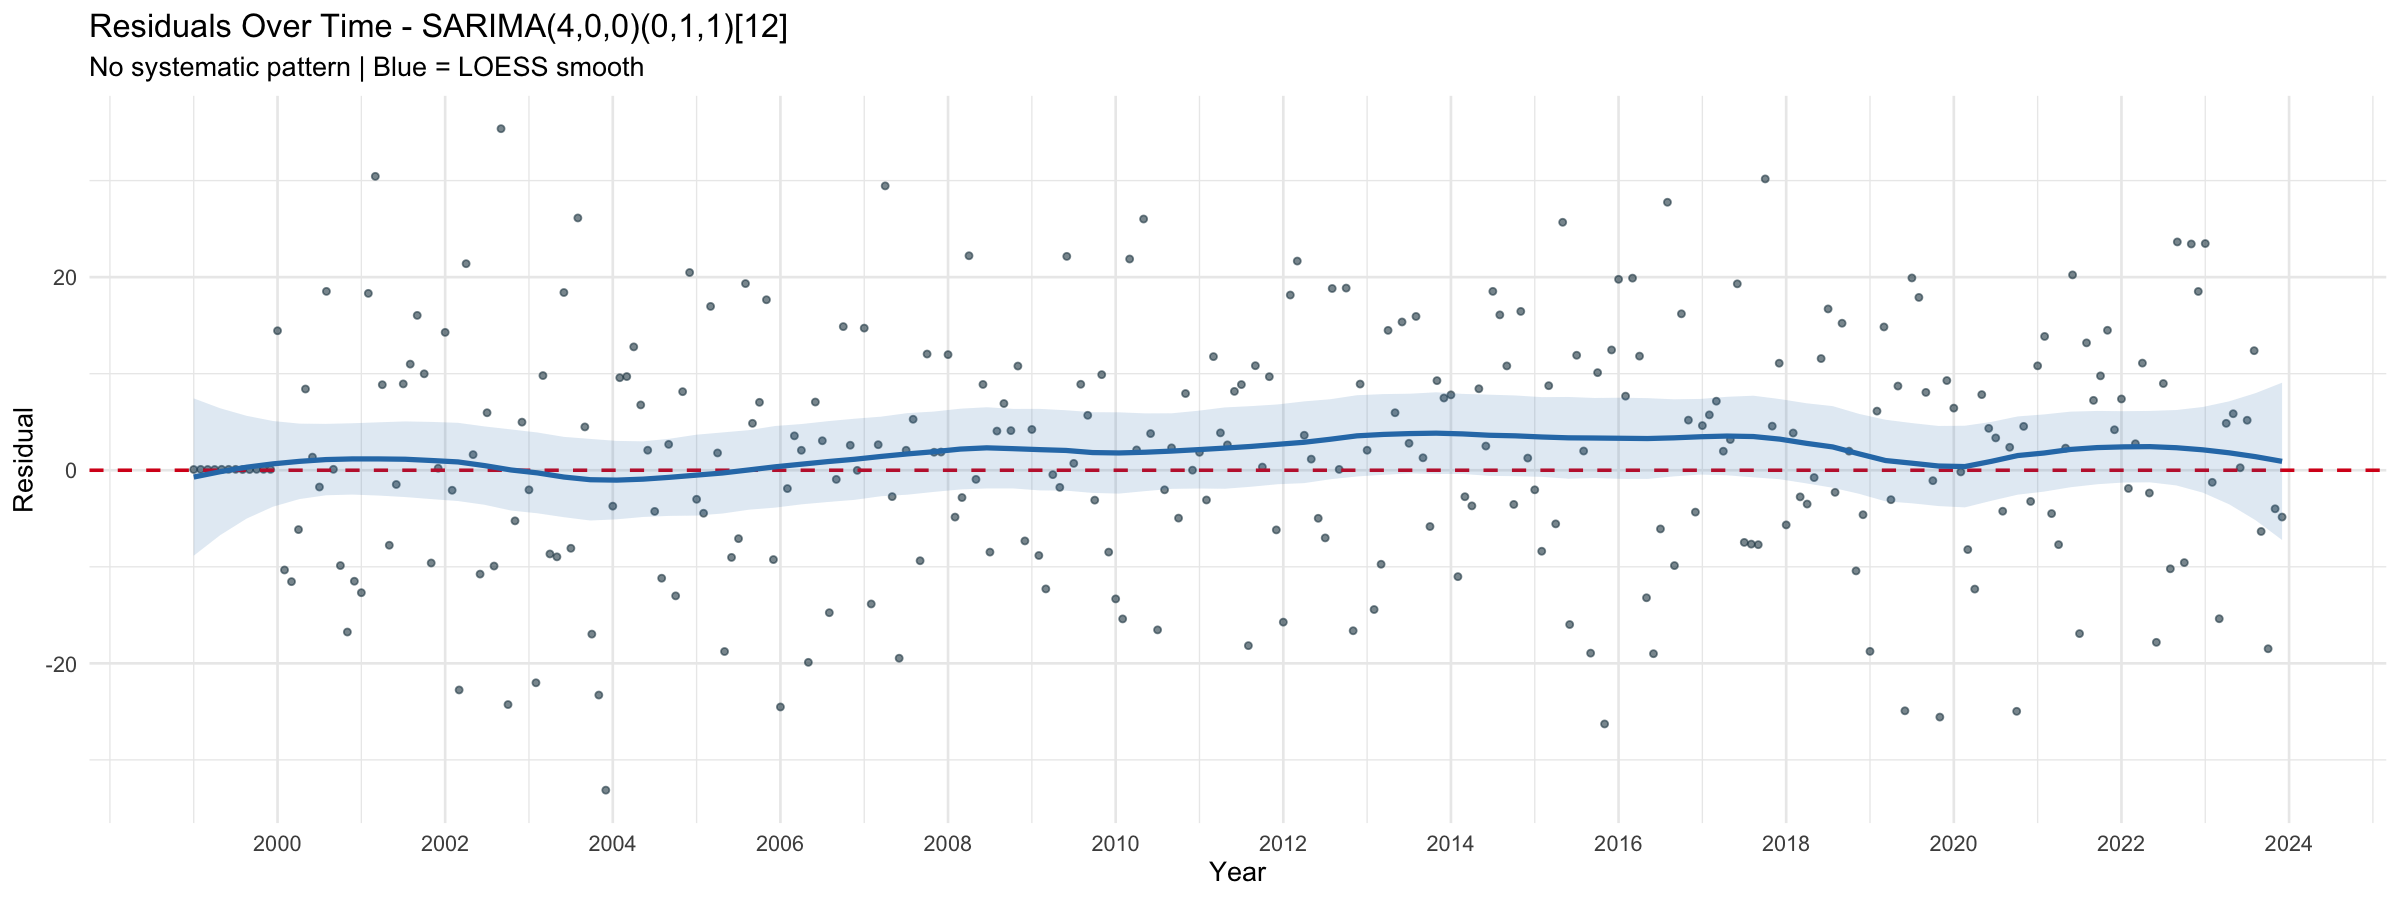

In [26]:
# SARIMA Residual Time Plot

options(repr.plot.width = 16, repr.plot.height = 6)
sarima_resid <- residuals(sarima_model)
resid_df <- data.frame(t = as.numeric(time(sarima_resid)), resid = as.numeric(sarima_resid))

ggplot(resid_df, aes(x = t, y = resid)) +
  geom_point(color = "#264653", size = 1.2, alpha = 0.6) +
  geom_hline(yintercept = 0, color = "#D7191C", linewidth = 0.8, linetype = "dashed") +
  geom_smooth(method = "loess", formula = y ~ x, span = 0.3, se = TRUE,
              color = "#2C7BB6", fill = "#2C7BB6", alpha = 0.15) +
  labs(title = "Residuals Over Time - SARIMA(4,0,0)(0,1,1)[12]",
       subtitle = "No systematic pattern | Blue = LOESS smooth",
       x = "Year", y = "Residual") +
  scale_x_continuous(breaks = seq(2000, 2024, 2))

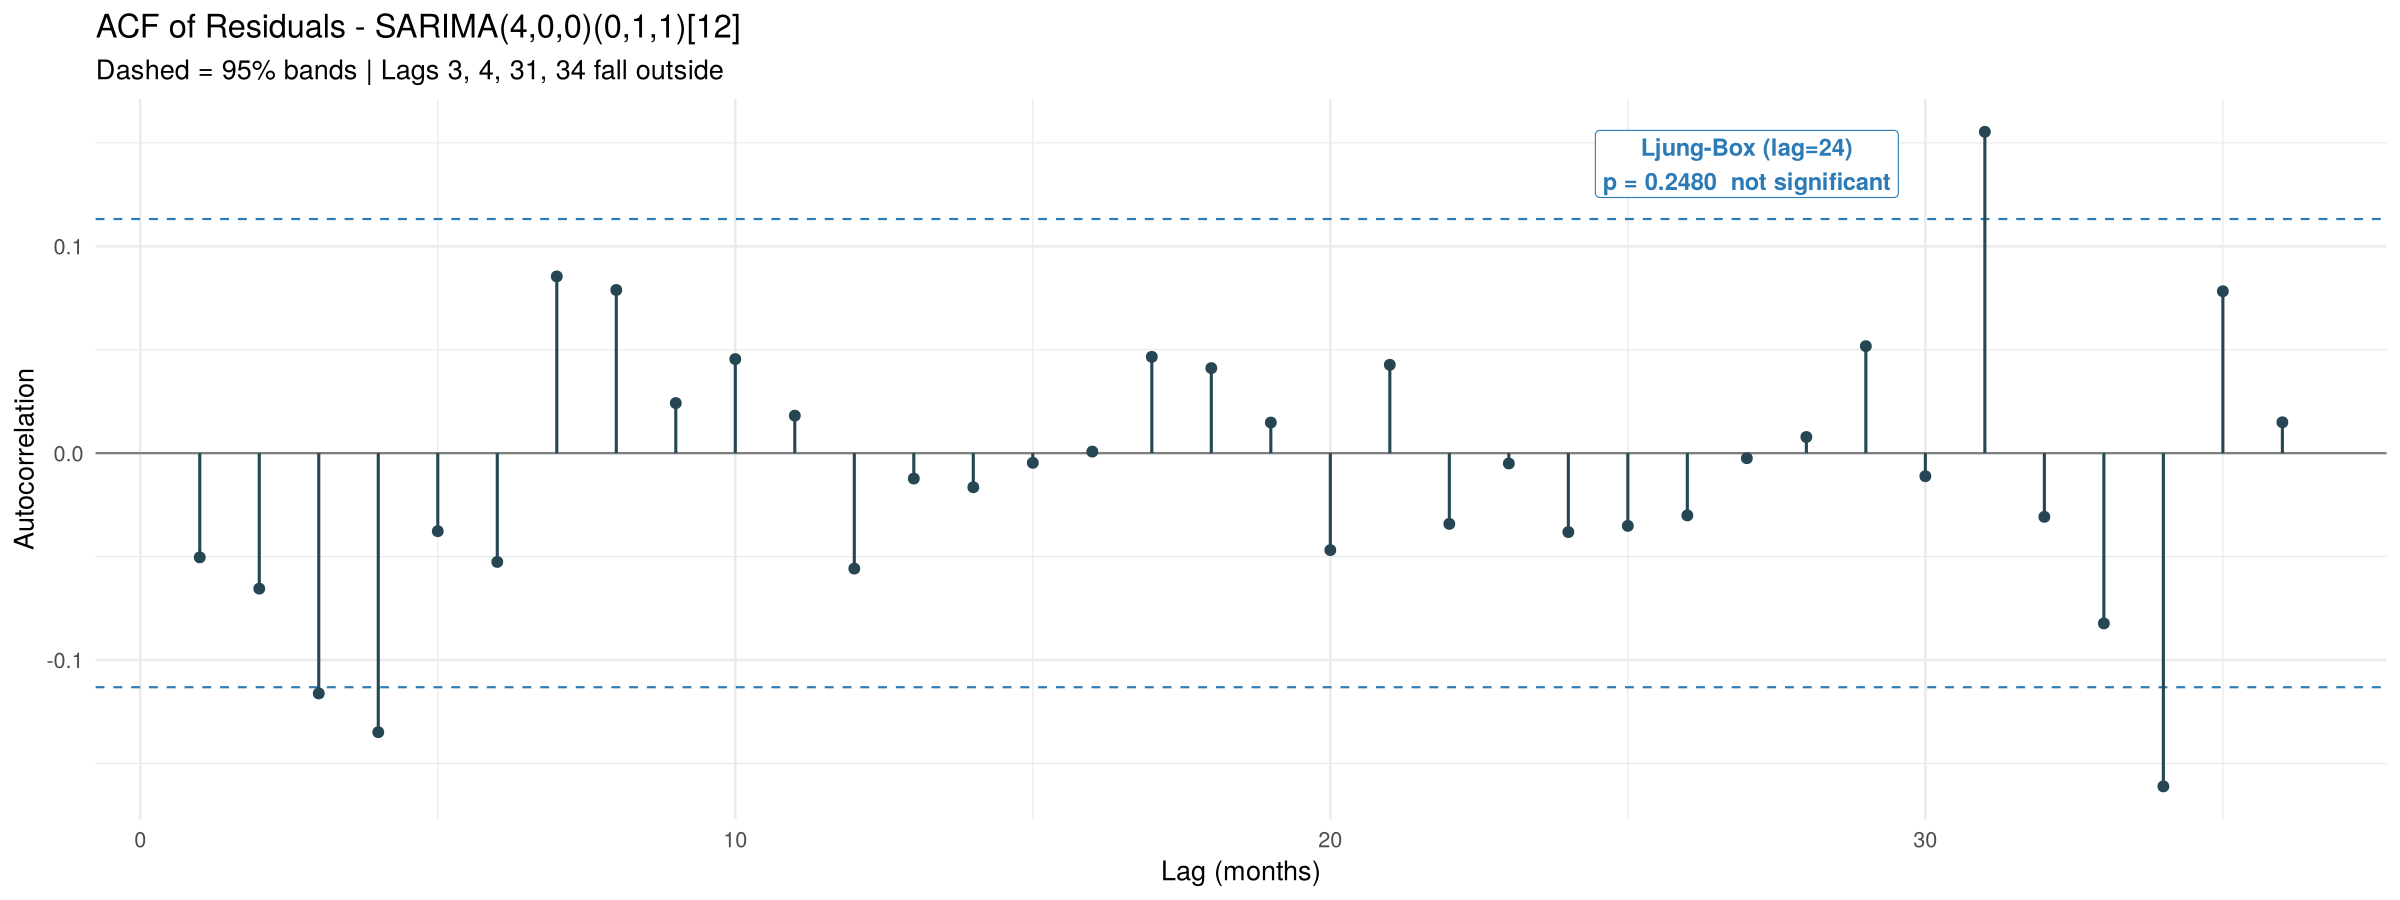

In [27]:
# SARIMA ACF of Residuals

acf_obj <- acf(sarima_resid, lag.max = 36, plot = FALSE)
acf_df  <- data.frame(lag = as.numeric(acf_obj$lag[-1]) * 12,
                      acf = as.numeric(acf_obj$acf[-1]))
ci <- qnorm(0.975) / sqrt(length(sarima_resid))

lb <- Box.test(residuals(sarima_model), lag = 24, type = "Ljung-Box", fitdf = 5)
lb_lab <- paste0("Ljung-Box (lag=24)\np = ", formatC(lb$p.value, format = "f", digits = 4),
                 ifelse(lb$p.value > 0.05, "  not significant", ""))

ggplot(acf_df, aes(x = lag, y = acf)) +
  geom_hline(yintercept = 0, color = "grey50") +
  geom_hline(yintercept = c(ci, -ci), linetype = "dashed", color = "#2C7BB6") +
  geom_segment(aes(xend = lag, yend = 0), color = "#264653", linewidth = 0.7) +
  geom_point(color = "#264653", size = 2) +
  annotate("label", x = max(acf_df$lag) * 0.75, y = max(acf_df$acf) * 0.9,
           label = lb_lab, fill = "white", color = "#2C7BB6", size = 4, fontface = "bold") +
  labs(title = "ACF of Residuals - SARIMA(4,0,0)(0,1,1)[12]",
       subtitle = "Dashed = 95% bands | Lags 3, 4, 31, 34 fall outside",
       x = "Lag (months)", y = "Autocorrelation")

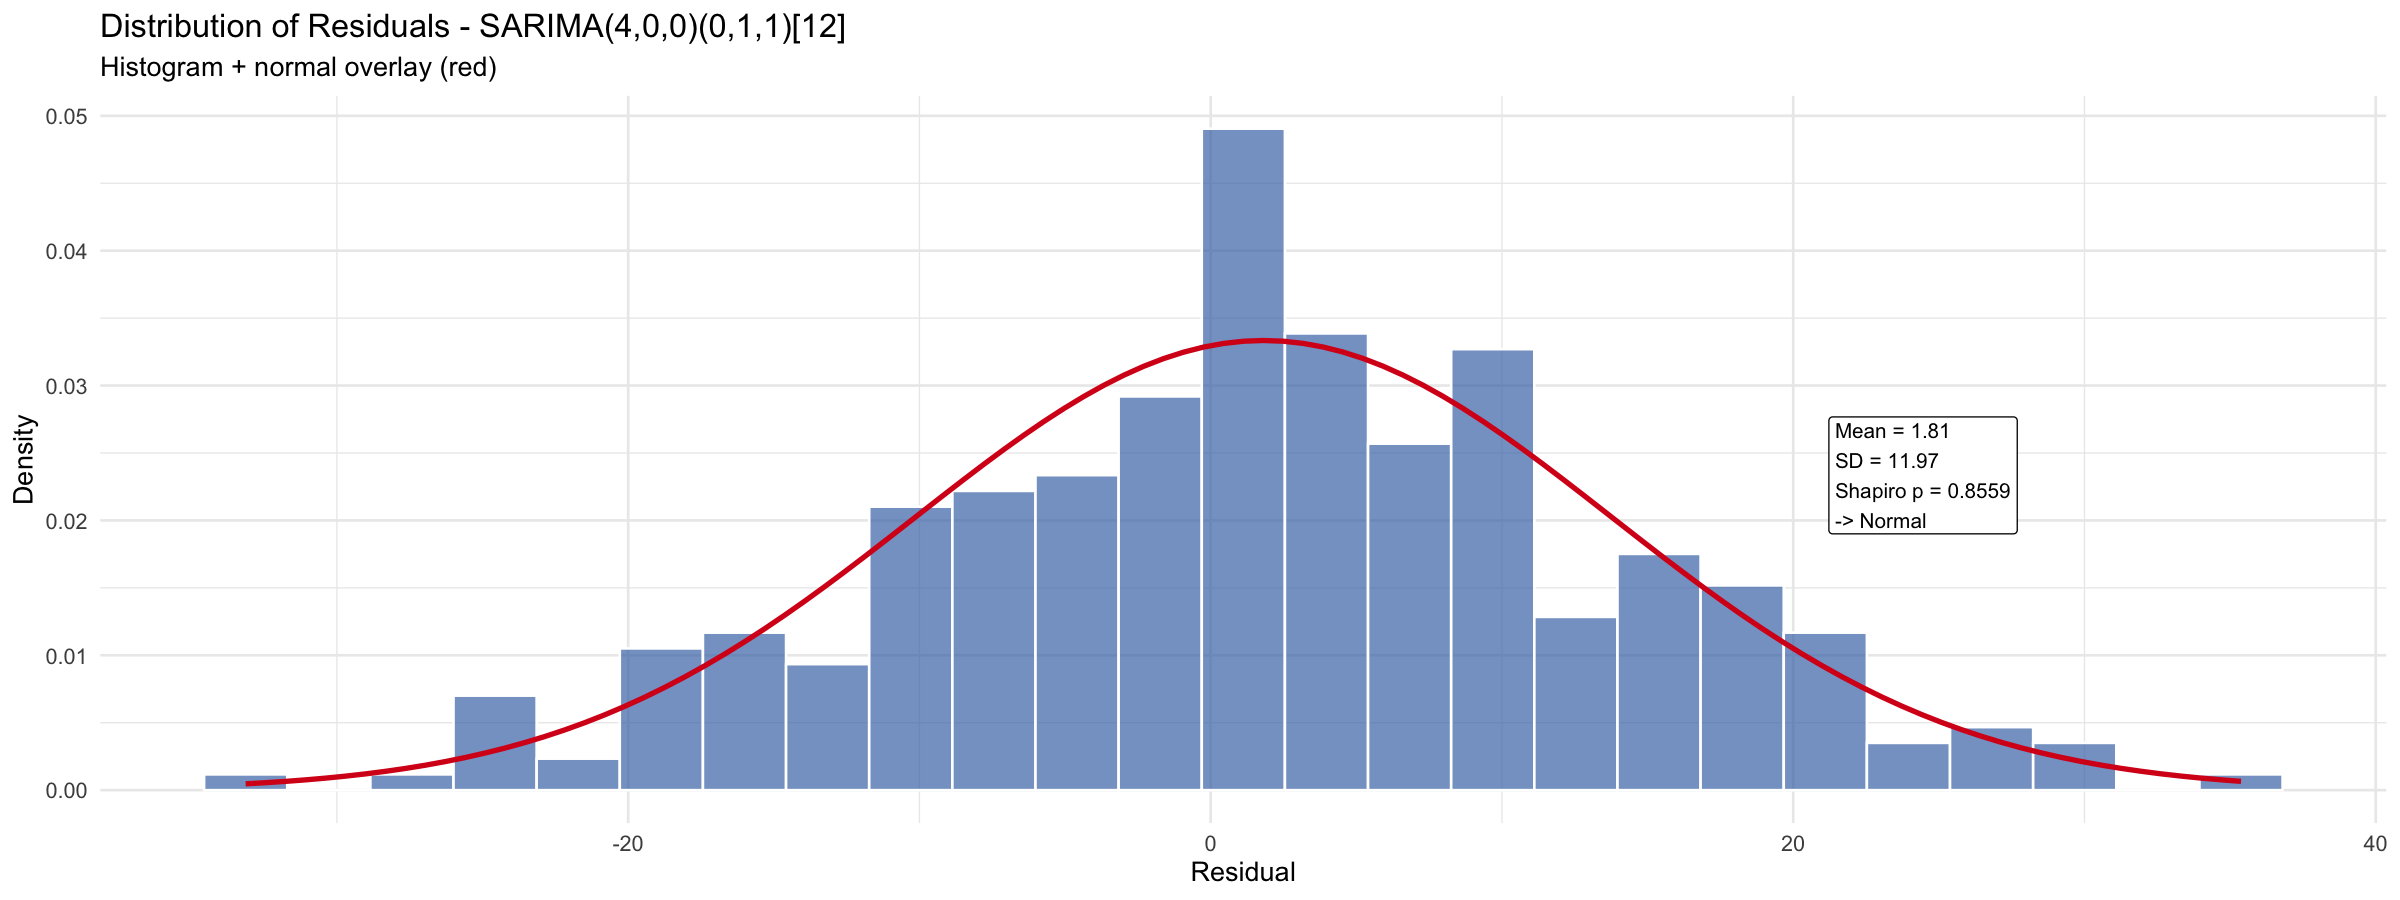

In [28]:
# SARIMA Histogram of Residuals

rc    <- na.omit(as.numeric(sarima_resid))
r_mu  <- mean(rc); r_sd <- sd(rc)
sw    <- shapiro.test(rc)
sw_lb <- paste0("Mean = ", round(r_mu, 2), "\nSD = ", round(r_sd, 2),
                "\nShapiro p = ", formatC(sw$p.value, format = "f", digits = 4),
                ifelse(sw$p.value > 0.05, "\n-> Normal", "\n-> Approx. Normal"))

ggplot(data.frame(r = rc), aes(x = r)) +
  geom_histogram(aes(y = after_stat(density)), bins = 25, fill = "#4575B4", alpha = 0.7, color = "white") +
  stat_function(fun = dnorm, args = list(mean = r_mu, sd = r_sd), color = "#D7191C", linewidth = 1.2) +
  annotate("label", x = max(rc) * 0.6, y = dnorm(r_mu, r_mu, r_sd) * 0.7,
           label = sw_lb, fill = "white", size = 3.5, hjust = 0) +
  labs(title = "Distribution of Residuals - SARIMA(4,0,0)(0,1,1)[12]",
       subtitle = "Histogram + normal overlay (red)", x = "Residual", y = "Density")